# Part-1: Installation & Setup
- Create Kaggle Notebook
- Create Kaggle Dataset
- Hugging Face Login
- W&B Setup



In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ruhulaminrakib/claim-annotation-sample-annotated/claim_annotation_sample_annotated.csv
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon_products_b1.faiss
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon_product_embeddings_b1.npy
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_train_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_test_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_corpus_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/scifact/scifact_dev_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon/amazon_claims_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/amazon/amazon_products_agrvf.parquet
/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/claims/agrvf_claim_candidates_v1.parquet
/kaggle/input/datasets/ruhulaminrakib

- Create Project Structure

In [2]:
import os

BASE = "/kaggle/working/AGRVF"

folders = [
    "data/raw",
    "data/processed",
    "data/external",
    "embeddings",
    "knowledge_graph",
    "retrieval",
    "claim_extraction",
    "aecs",
    "verification",
    "llm",
    "evaluation",
    "results",
    "logs"
]

for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("AGRVF project structure created.")

AGRVF project structure created.


- Install Core Packages

In [3]:
!pip install -q \
    transformers \
    datasets \
    sentence-transformers \
    accelerate \
    faiss-cpu \
    pandas \
    numpy \
    scikit-learn \
    scipy \
    networkx \
    spacy \
    nltk \
    beautifulsoup4 \
    lxml \
    rank-bm25 \
    evaluate \
    captum \
    shap \
    neo4j \
    huggingface_hub \
    wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 70.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.5/331.5 kB 15.2 MB/s eta 0:00:00


- Verify GPU

In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


- Verify Main Libraries

In [5]:
import transformers
import datasets
import sentence_transformers
import faiss
import pandas
import sklearn
import networkx

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)
print("FAISS:", faiss.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("NetworkX:", networkx.__version__)

Transformers: 5.0.0
Datasets: 5.0.0
Sentence Transformers: 5.4.1
FAISS: 1.15.1
Pandas: 2.3.3
Scikit-learn: 1.6.1
NetworkX: 3.6.1


- Kaggle API / Dataset Access

In [6]:
import os

os.makedirs("/kaggle/working/datasets", exist_ok=True)

In [7]:
from datasets import load_dataset

In [8]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Get Hugging Face token from Kaggle Secrets
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Authenticate with Hugging Face
login(token=hf_token)

print("Hugging Face authentication successful.")

Hugging Face authentication successful.


In [9]:
!pip install -q wandb

In [10]:
import wandb

- WANDB login

In [11]:
from kaggle_secrets import UserSecretsClient
import wandb

# Access Kaggle Secrets
user_secrets = UserSecretsClient()

# Get W&B API key securely
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

# Log in to Weights & Biases
wandb.login(key=wandb_api_key)

print("W&B login successful.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ruhul-amin (ruhul-amin-american-international-university-bangladesh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login successful.


- Create Experiment Configuration

In [12]:
CONFIG = {
    "project": "AGRVF",
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "embedding_model": "BAAI/bge-large-en-v1.5",

    "claim_llm": "Qwen",

    "retrieval_top_k": 20,

    "verification_top_k": 5,

    "random_seed": 42
}

CONFIG

{'project': 'AGRVF',
 'device': 'cuda',
 'embedding_model': 'BAAI/bge-large-en-v1.5',
 'claim_llm': 'Qwen',
 'retrieval_top_k': 20,
 'verification_top_k': 5,
 'random_seed': 42}

- Reproducibility Setup

In [13]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


# Part 2 — Authentic Dataset Acquisition & Validation
## Datasets
- Amazon Reviews'23—All_Beauty->Product claims + reviews
- Amazon Reviews'23—metadata_All_Beauty->Product identification
- Open Beauty Facts->Ingredients/product knowledge
- FEVER->Claim/evidence verification pretraining
- SciFact->Scientific evidence retrieval/verification

## Set up the environment

In [14]:
import os
import json
import pandas as pd
import numpy as np

In [15]:
BASE = "/kaggle/working/AGRVF"

for folder in [
    "data/raw/amazon",
    "data/raw/openbeautyfacts",
    "data/raw/fever",
    "data/raw/scifact",
    "data/processed",
    "results/data_validation"
]:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("Dataset environment ready.")
print("Working directory:", BASE)

Dataset environment ready.
Working directory: /kaggle/working/AGRVF


- Install Required Libraries

In [16]:
!pip install -q datasets huggingface_hub pyarrow
!pip install -q datasets

## Amazon Reviews'23 — All Beauty

In [17]:
!pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 11.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 81.2 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


In [21]:
import os
import pandas as pd

INPUT_BASE = "/kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/AGRVF_Project_Storage"

REVIEW_FILE = os.path.join(
    INPUT_BASE,
    "raw",
    "amazon",
    "all_beauty_reviews.jsonl"
)

print("Review file:", REVIEW_FILE)
print("Exists:", os.path.exists(REVIEW_FILE))

Review file: /kaggle/input/datasets/ruhulaminrakib/agrvf-project-storage/AGRVF_Project_Storage/raw/amazon/all_beauty_reviews.jsonl
Exists: False


- Needs the raw `all_beauty_reviews.jsonl` dataset attached as input. Not required if you already have the processed outputs under `data/processed/`.

In [ ]:
reviews_df = pd.read_json(
    REVIEW_FILE,
    lines=True
)

print("Shape:", reviews_df.shape)

In [ ]:
print("Columns:")
print(reviews_df.columns.tolist())

In [ ]:
reviews_df.head(3)

- Check the dataset size

In [ ]:
print("Number of reviews:", len(reviews_df))
print("Number of columns:", len(reviews_df.columns))
print("Shape:", reviews_df.shape)

- Check the data types

In [ ]:
print(reviews_df.dtypes)

- Check missing values

In [ ]:
print("Missing values:")
print(reviews_df.isna().sum())

print("\nMissing percentage:")
print((reviews_df.isna().mean() * 100).round(2))

- Check duplicate reviews

In [ ]:
duplicate_reviews = reviews_df.duplicated(
    subset=[
        "rating",
        "title",
        "text",
        "asin",
        "parent_asin",
        "user_id",
        "timestamp"
    ]
).sum()

print("Duplicate reviews:", duplicate_reviews)

In [ ]:
duplicate_products = reviews_df["parent_asin"].duplicated().sum()

print("Duplicate parent_asin:", duplicate_products)

- Create the temporary text_length column

In [ ]:
reviews_df["text_length"] = (
    reviews_df["text"]
    .fillna("")
    .astype(str)
    .str.len()
)

- View the statistics

In [ ]:
print(reviews_df["text_length"].describe())

- Check empty and very short reviews

In [ ]:
empty_reviews = (reviews_df["text_length"] == 0).sum()

print("Empty reviews:", empty_reviews)

In [ ]:
very_short_reviews = (
    reviews_df["text_length"] < 10
).sum()

print("Reviews shorter than 10 characters:", very_short_reviews)

- all rating values

In [ ]:
print("Unique ratings:")
print(sorted(reviews_df["rating"].dropna().unique()))

In [ ]:
print("Rating distribution:")
print(
    reviews_df["rating"]
    .value_counts(dropna=False)
    .sort_index()
)

In [ ]:
invalid_ratings = reviews_df[
    ~reviews_df["rating"].isin([1, 2, 3, 4, 5])
]

print("Invalid ratings:", len(invalid_ratings))

In [ ]:
print(
    "Missing ratings:",
    reviews_df["rating"].isna().sum()
)

## Amazon All_Beauty Product Metadata

In [ ]:
import os
import pandas as pd

METADATA_FILE = os.path.join(
    INPUT_BASE,
    "raw",
    "amazon",
    "meta_all_beauty.jsonl"
)

print("Metadata file:", METADATA_FILE)
print("Exists:", os.path.exists(METADATA_FILE))

In [ ]:
metadata_df = pd.read_json(
    METADATA_FILE,
    lines=True
)

print("Shape:", metadata_df.shape)

In [ ]:
print("Columns:")
print(metadata_df.columns.tolist())

In [ ]:
metadata_df.head(3)

- Validate Amazon Product Metadata

In [ ]:
print("Missing values:")
print(metadata_df.isna().sum())

print("\nMissing percentage:")
print(
    (metadata_df.isna().mean() * 100)
    .round(2)
)

In [ ]:
duplicate_metadata = metadata_df["parent_asin"].duplicated().sum()

print("Duplicate parent_asin:", duplicate_metadata)

In [ ]:
missing_titles = metadata_df["title"].isna().sum()

print("Missing product titles:", missing_titles)

In [ ]:
empty_titles = (
    metadata_df["title"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty product titles:", empty_titles)

In [ ]:
missing_descriptions = metadata_df["description"].isna().sum()

print("Missing descriptions:", missing_descriptions)

In [ ]:
print("Average rating statistics:")
print(metadata_df["average_rating"].describe())

In [ ]:
print("\nUnique average ratings outside 0-5:")

invalid_avg = metadata_df[
    (metadata_df["average_rating"] < 0) |
    (metadata_df["average_rating"] > 5)
]

print("Invalid average ratings:", len(invalid_avg))

In [ ]:
print(
    "Missing average_rating:",
    metadata_df["average_rating"].isna().sum()
)

In [ ]:
print("Rating number statistics:")
print(metadata_df["rating_number"].describe())

In [ ]:
invalid_rating_number = metadata_df[
    metadata_df["rating_number"] < 0
]

print(
    "Invalid negative rating_number:",
    len(invalid_rating_number)
)

In [ ]:
zero_rating_number = (
    metadata_df["rating_number"] == 0
).sum()

print(
    "Products with rating_number = 0:",
    zero_rating_number
)

## Open Beauty Facts

In [ ]:
import os

OPENBEAUTY_FILE = os.path.join(
    INPUT_BASE,
    "raw",
    "openbeautyfacts",
    "fr.openbeautyfacts.org.products.csv"
)

print("Open Beauty Facts file:")
print(OPENBEAUTY_FILE)

print("\nExists:", os.path.exists(OPENBEAUTY_FILE))

In [ ]:
file_size_gb = os.path.getsize(OPENBEAUTY_FILE) / (1024 ** 3)

print(f"File size: {file_size_gb:.2f} GB")

In [ ]:
beauty_df = pd.read_csv(
    OPENBEAUTY_FILE,
    sep="\t",
    low_memory=False
)

print("Shape:", beauty_df.shape)

In [ ]:
print("Number of columns:", len(beauty_df.columns))
print("\nColumns:")
print(beauty_df.columns.tolist())

In [ ]:
beauty_df.head(3)

- Validate Open Beauty Facts

In [ ]:
target_columns = [
    "code",
    "product_name",
    "brands",
    "categories",
    "ingredients_text",
    "countries",
    "labels"
]

print("Missing values:")
print(beauty_df[target_columns].isna().sum())

print("\nMissing percentage:")
print(
    (beauty_df[target_columns].isna().mean() * 100)
    .round(2)
)

In [ ]:
duplicate_codes = beauty_df["code"].duplicated().sum()

print("Duplicate product codes:", duplicate_codes)

In [ ]:
empty_product_names = (
    beauty_df["product_name"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty product names:", empty_product_names)

In [ ]:
empty_ingredients = (
    beauty_df["ingredients_text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty ingredients_text:", empty_ingredients)

- Inspect Open Beauty Facts Content

In [ ]:
ingredient_examples = beauty_df[
    beauty_df["ingredients_text"].notna()
    & beauty_df["ingredients_text"].astype(str).str.strip().ne("")
][
    [
        "code",
        "product_name",
        "brands",
        "categories",
        "ingredients_text"
    ]
].head(10)

ingredient_examples

In [ ]:
ingredient_lengths = (
    beauty_df["ingredients_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

print(ingredient_lengths.describe())

In [ ]:
product_name_examples = beauty_df[
    beauty_df["product_name"].notna()
    & beauty_df["product_name"].astype(str).str.strip().ne("")
][
    [
        "code",
        "product_name",
        "brands",
        "categories"
    ]
].head(10)

product_name_examples

In [ ]:
print(
    beauty_df["countries"]
    .value_counts(dropna=False)
    .head(20)
)

## Open Beauty Facts AGRVF Subset Create

In [ ]:
beauty_required_columns = [
    "code",
    "product_name",
    "brands",
    "categories",
    "ingredients_text",
    "countries",
    "labels"
]

beauty_processed = beauty_df[beauty_required_columns].copy()

print("Original shape:", beauty_df.shape)
print("AGRVF subset shape:", beauty_processed.shape)

print("\nColumns:")
print(beauty_processed.columns.tolist())

In [ ]:
import os

BASE = "/kaggle/working/AGRVF"

PROCESSED_OPENBEAUTY_DIR = os.path.join(
    BASE,
    "data",
    "processed",
    "openbeautyfacts"
)

os.makedirs(
    PROCESSED_OPENBEAUTY_DIR,
    exist_ok=True
)

print("Processed directory:")
print(PROCESSED_OPENBEAUTY_DIR)

print("Exists:", os.path.exists(PROCESSED_OPENBEAUTY_DIR))

In [ ]:
processed_file = os.path.join(
    PROCESSED_OPENBEAUTY_DIR,
    "openbeautyfacts_agrvf.parquet"
)

beauty_processed.to_parquet(
    processed_file,
    index=False
)

print("Saved Open Beauty Facts AGRVF subset.")
print("File:", processed_file)

In [ ]:
print("File exists:", os.path.exists(processed_file))

if os.path.exists(processed_file):
    print(
        "File size:",
        round(os.path.getsize(processed_file) / (1024 ** 2), 2),
        "MB"
    )

## Validate FEVER dataset.

In [ ]:
FEVER_FILE = os.path.join(
    INPUT_BASE,
    "raw",
    "fever",
    "train.jsonl"
)

print("FEVER file:")
print(FEVER_FILE)

print("Exists:", os.path.exists(FEVER_FILE))

In [ ]:
fever_df = pd.read_json(
    FEVER_FILE,
    lines=True
)

print("Shape:", fever_df.shape)

In [ ]:
print("Columns:")
print(fever_df.columns.tolist())

In [ ]:
fever_df.head(3)

- Validation

In [ ]:
print("Missing values:")
print(fever_df.isna().sum())

print("\nMissing percentage:")
print(
    (fever_df.isna().mean() * 100).round(2)
)

In [ ]:
print("Label distribution:")
print(fever_df["label"].value_counts(dropna=False))

In [ ]:
print("Verifiable distribution:")
print(fever_df["verifiable"].value_counts(dropna=False))

In [ ]:
empty_claims = (
    fever_df["claim"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty claims:", empty_claims)

In [ ]:
duplicate_claims = fever_df["claim"].duplicated().sum()

print("Duplicate claims:", duplicate_claims)

In [ ]:
fever_required_columns = [
    "id",
    "verifiable",
    "label",
    "claim",
    "evidence"
]

fever_processed = fever_df[fever_required_columns].copy()

print("Original shape:", fever_df.shape)
print("AGRVF subset shape:", fever_processed.shape)

print("\nColumns:")
print(fever_processed.columns.tolist())

In [ ]:
PROCESSED_FEVER_DIR = os.path.join(
    BASE,
    "data",
    "processed",
    "fever"
)

os.makedirs(
    PROCESSED_FEVER_DIR,
    exist_ok=True
)

print("Processed directory:")
print(PROCESSED_FEVER_DIR)

print("Exists:", os.path.exists(PROCESSED_FEVER_DIR))

In [ ]:
import json

fever_processed = fever_df[
    [
        "id",
        "verifiable",
        "label",
        "claim",
        "evidence"
    ]
].copy()

# Convert nested evidence structures into JSON strings
fever_processed["evidence"] = fever_processed["evidence"].apply(
    lambda x: json.dumps(x, ensure_ascii=False)
)

print(fever_processed.dtypes)

In [ ]:
fever_processed_file = os.path.join(
    PROCESSED_FEVER_DIR,
    "fever_train_agrvf.parquet"
)

fever_processed.to_parquet(
    fever_processed_file,
    index=False
)

print("Saved FEVER AGRVF subset.")
print("File:", fever_processed_file)

In [ ]:
print("File exists:", os.path.exists(fever_processed_file))

if os.path.exists(fever_processed_file):
    print(
        "File size:",
        round(
            os.path.getsize(fever_processed_file) / (1024 ** 2),
            2
        ),
        "MB"
    )

## SciFact

In [ ]:
SCIFACT_DIR = os.path.join(
    INPUT_BASE,
    "raw",
    "scifact"
)

print("SciFact directory:")
print(SCIFACT_DIR)

print("Exists:", os.path.exists(SCIFACT_DIR))

In [ ]:
SCIFACT_FILES = {
    "train": os.path.join(SCIFACT_DIR, "claims_train.jsonl"),
    "dev": os.path.join(SCIFACT_DIR, "claims_dev.jsonl"),
    "test": os.path.join(SCIFACT_DIR, "claims_test.jsonl"),
    "corpus": os.path.join(SCIFACT_DIR, "corpus.jsonl")
}

for name, path in SCIFACT_FILES.items():
    print(f"{name}: {os.path.exists(path)}")
    print(f"  {path}")

In [ ]:
scifact_train_df = pd.read_json(
    SCIFACT_FILES["train"],
    lines=True
)

print("Training shape:", scifact_train_df.shape)
print("Columns:", scifact_train_df.columns.tolist())

In [ ]:
scifact_dev_df = pd.read_json(
    SCIFACT_FILES["dev"],
    lines=True
)

print("Development shape:", scifact_dev_df.shape)
print("Columns:", scifact_dev_df.columns.tolist())

In [ ]:
scifact_test_df = pd.read_json(
    SCIFACT_FILES["test"],
    lines=True
)

print("Test shape:", scifact_test_df.shape)
print("Columns:", scifact_test_df.columns.tolist())

In [ ]:
scifact_corpus_df = pd.read_json(
    SCIFACT_FILES["corpus"],
    lines=True
)

print("Corpus shape:", scifact_corpus_df.shape)
print("Columns:", scifact_corpus_df.columns.tolist())

- SciFact Validation

In [ ]:
print("=== SciFact TRAIN ===")

print("Shape:", scifact_train_df.shape)

print("\nMissing values:")
print(scifact_train_df.isna().sum())

print("\nMissing percentage:")
print(
    (scifact_train_df.isna().mean() * 100).round(2)
)

print("\nDuplicate IDs:",
      scifact_train_df["id"].duplicated().sum())

print("Duplicate claims:",
      scifact_train_df["claim"].duplicated().sum())

print("Empty claims:",
      scifact_train_df["claim"].fillna("").str.strip().eq("").sum())

In [ ]:
print("=== SciFact DEV ===")

print("Shape:", scifact_dev_df.shape)

print("\nMissing values:")
print(scifact_dev_df.isna().sum())

print("\nMissing percentage:")
print(
    (scifact_dev_df.isna().mean() * 100).round(2)
)

print("\nDuplicate IDs:",
      scifact_dev_df["id"].duplicated().sum())

print("Duplicate claims:",
      scifact_dev_df["claim"].duplicated().sum())

print("Empty claims:",
      scifact_dev_df["claim"].fillna("").str.strip().eq("").sum())

In [ ]:
print("=== SciFact TEST ===")

print("Shape:", scifact_test_df.shape)

print("\nMissing values:")
print(scifact_test_df.isna().sum())

print("\nDuplicate IDs:",
      scifact_test_df["id"].duplicated().sum())

print("Duplicate claims:",
      scifact_test_df["claim"].duplicated().sum())

print("Empty claims:",
      scifact_test_df["claim"].fillna("").str.strip().eq("").sum())

In [ ]:
print("=== SciFact CORPUS ===")

print("Shape:", scifact_corpus_df.shape)

print("\nMissing values:")
print(scifact_corpus_df.isna().sum())

print("\nMissing percentage:")
print(
    (scifact_corpus_df.isna().mean() * 100).round(2)
)

print("\nDuplicate document IDs:",
      scifact_corpus_df["doc_id"].duplicated().sum())

print("Duplicate titles:",
      scifact_corpus_df["title"].duplicated().sum())

print("Empty titles:",
      scifact_corpus_df["title"].fillna("").str.strip().eq("").sum())

print("Empty abstracts:",
      scifact_corpus_df["abstract"].fillna("").str.strip().eq("").sum())

In [ ]:
scifact_train_df["claim_length"] = (
    scifact_train_df["claim"]
    .fillna("")
    .str.len()
)

print(scifact_train_df["claim_length"].describe())

In [ ]:
scifact_corpus_df["abstract_length"] = (
    scifact_corpus_df["abstract"]
    .fillna("")
    .str.len()
)

print(scifact_corpus_df["abstract_length"].describe())

In [ ]:
train_cited_ids = set()

for ids in scifact_train_df["cited_doc_ids"]:
    if isinstance(ids, list):
        train_cited_ids.update(ids)

print("Unique cited document IDs in TRAIN:",
      len(train_cited_ids))

In [ ]:
dev_cited_ids = set()

for ids in scifact_dev_df["cited_doc_ids"]:
    if isinstance(ids, list):
        dev_cited_ids.update(ids)

print("Unique cited document IDs in DEV:",
      len(dev_cited_ids))

In [ ]:
corpus_doc_ids = set(
    scifact_corpus_df["doc_id"]
)

print("Unique corpus document IDs:",
      len(corpus_doc_ids))

In [ ]:
missing_train_docs = (
    train_cited_ids - corpus_doc_ids
)

missing_dev_docs = (
    dev_cited_ids - corpus_doc_ids
)

print(
    "TRAIN cited documents missing from corpus:",
    len(missing_train_docs)
)

print(
    "DEV cited documents missing from corpus:",
    len(missing_dev_docs)
)

In [ ]:
print("Example TRAIN evidence:")
print(scifact_train_df["evidence"].iloc[0])

print("\nExample cited document IDs:")
print(scifact_train_df["cited_doc_ids"].iloc[0])

- Create the SciFact Layer

In [ ]:
SCIFACT_PROCESSED_DIR = os.path.join(
    BASE,
    "data",
    "processed",
    "scifact"
)

os.makedirs(
    SCIFACT_PROCESSED_DIR,
    exist_ok=True
)

print("Processed directory:")
print(SCIFACT_PROCESSED_DIR)

print("Exists:", os.path.exists(SCIFACT_PROCESSED_DIR))

In [ ]:
import json

scifact_train_processed = scifact_train_df[
    [
        "id",
        "claim",
        "evidence",
        "cited_doc_ids"
    ]
].copy()

scifact_train_processed["evidence"] = (
    scifact_train_processed["evidence"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

scifact_train_processed["cited_doc_ids"] = (
    scifact_train_processed["cited_doc_ids"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

print(scifact_train_processed.dtypes)
print(scifact_train_processed.shape)

In [ ]:
scifact_dev_processed = scifact_dev_df[
    [
        "id",
        "claim",
        "evidence",
        "cited_doc_ids"
    ]
].copy()

scifact_dev_processed["evidence"] = (
    scifact_dev_processed["evidence"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

scifact_dev_processed["cited_doc_ids"] = (
    scifact_dev_processed["cited_doc_ids"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

print(scifact_dev_processed.dtypes)
print(scifact_dev_processed.shape)

In [ ]:
scifact_test_processed = scifact_test_df[
    [
        "id",
        "claim"
    ]
].copy()

print(scifact_test_processed.dtypes)
print(scifact_test_processed.shape)

In [ ]:
scifact_corpus_processed = scifact_corpus_df[
    [
        "doc_id",
        "title",
        "abstract",
        "structured"
    ]
].copy()

scifact_corpus_processed["structured"] = (
    scifact_corpus_processed["structured"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

print(scifact_corpus_processed.dtypes)
print(scifact_corpus_processed.shape)

In [ ]:
scifact_train_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_train_agrvf.parquet"
)

scifact_train_processed.to_parquet(
    scifact_train_file,
    index=False
)

print("Saved:", scifact_train_file)

In [ ]:
scifact_dev_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_dev_agrvf.parquet"
)

scifact_dev_processed.to_parquet(
    scifact_dev_file,
    index=False
)

print("Saved:", scifact_dev_file)

In [ ]:
scifact_test_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_test_agrvf.parquet"
)

scifact_test_processed.to_parquet(
    scifact_test_file,
    index=False
)

print("Saved:", scifact_test_file)

In [ ]:
scifact_corpus_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_corpus_agrvf.parquet"
)

scifact_corpus_processed.to_parquet(
    scifact_corpus_file,
    index=False
)

print("Saved:", scifact_corpus_file)

In [ ]:
scifact_processed_files = [
    scifact_train_file,
    scifact_dev_file,
    scifact_test_file,
    scifact_corpus_file
]

print("=== SciFact Processed Files ===")

for file in scifact_processed_files:
    exists = os.path.exists(file)

    print(
        os.path.basename(file),
        "| Exists:", exists,
        "| Size:",
        round(os.path.getsize(file) / (1024 ** 2), 2)
        if exists else "N/A",
        "MB"
    )

- Prepare SciFact

In [ ]:
SCIFACT_PROCESSED_DIR = os.path.join(
    BASE,
    "data",
    "processed",
    "scifact"
)

os.makedirs(
    SCIFACT_PROCESSED_DIR,
    exist_ok=True
)

print("Processed directory:")
print(SCIFACT_PROCESSED_DIR)

print("Exists:", os.path.exists(SCIFACT_PROCESSED_DIR))

In [ ]:
print("SciFact train:", scifact_train_df.shape)
print("SciFact dev:", scifact_dev_df.shape)
print("SciFact test:", scifact_test_df.shape)
print("SciFact corpus:", scifact_corpus_df.shape)

In [ ]:
import json

scifact_train_processed = scifact_train_df[
    [
        "id",
        "claim",
        "evidence",
        "cited_doc_ids"
    ]
].copy()

# Preserve nested evidence as JSON text
scifact_train_processed["evidence"] = (
    scifact_train_processed["evidence"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

# Preserve cited document IDs as JSON text
scifact_train_processed["cited_doc_ids"] = (
    scifact_train_processed["cited_doc_ids"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

print("Shape:", scifact_train_processed.shape)
print("Columns:", scifact_train_processed.columns.tolist())
print("\nData types:")
print(scifact_train_processed.dtypes)

In [ ]:
scifact_train_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_train_agrvf.parquet"
)

scifact_train_processed.to_parquet(
    scifact_train_file,
    index=False
)

print("Saved SciFact training file.")
print("File:", scifact_train_file)

print(
    "File size:",
    round(
        os.path.getsize(scifact_train_file) / (1024 ** 2),
        2
    ),
    "MB"
)

In [ ]:
print(
    "Exists:",
    os.path.exists(scifact_train_file)
)

In [ ]:
scifact_dev_processed = scifact_dev_df[
    [
        "id",
        "claim",
        "evidence",
        "cited_doc_ids"
    ]
].copy()

scifact_dev_processed["evidence"] = (
    scifact_dev_processed["evidence"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

scifact_dev_processed["cited_doc_ids"] = (
    scifact_dev_processed["cited_doc_ids"]
    .apply(lambda x: json.dumps(x, ensure_ascii=False))
)

print("Shape:", scifact_dev_processed.shape)
print("Columns:", scifact_dev_processed.columns.tolist())

print("\nData types:")
print(scifact_dev_processed.dtypes)

In [ ]:
scifact_dev_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_dev_agrvf.parquet"
)

scifact_dev_processed.to_parquet(
    scifact_dev_file,
    index=False
)

print("Saved SciFact development file.")
print("File:", scifact_dev_file)

print(
    "File size:",
    round(
        os.path.getsize(scifact_dev_file) / (1024 ** 2),
        2
    ),
    "MB"
)

print("Exists:", os.path.exists(scifact_dev_file))

In [ ]:
scifact_test_processed = scifact_test_df[
    [
        "id",
        "claim"
    ]
].copy()

print("Shape:", scifact_test_processed.shape)
print("Columns:", scifact_test_processed.columns.tolist())

print("\nData types:")
print(scifact_test_processed.dtypes)

In [ ]:
scifact_test_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_test_agrvf.parquet"
)

scifact_test_processed.to_parquet(
    scifact_test_file,
    index=False
)

print("Saved SciFact test file.")
print("File:", scifact_test_file)

print(
    "File size:",
    round(
        os.path.getsize(scifact_test_file) / (1024 ** 2),
        2
    ),
    "MB"
)

print("Exists:", os.path.exists(scifact_test_file))

In [ ]:
scifact_corpus_processed = scifact_corpus_df[
    [
        "doc_id",
        "title",
        "abstract",
        "structured"
    ]
].copy()

print("Shape:", scifact_corpus_processed.shape)
print("Columns:", scifact_corpus_processed.columns.tolist())

print("\nData types:")
print(scifact_corpus_processed.dtypes)

In [ ]:
scifact_corpus_file = os.path.join(
    SCIFACT_PROCESSED_DIR,
    "scifact_corpus_agrvf.parquet"
)

scifact_corpus_processed.to_parquet(
    scifact_corpus_file,
    index=False
)

print("Saved SciFact corpus.")
print("File:", scifact_corpus_file)

print(
    "File size:",
    round(
        os.path.getsize(scifact_corpus_file) / (1024 ** 2),
        2
    ),
    "MB"
)

print("Exists:", os.path.exists(scifact_corpus_file))

In [ ]:
import pandas as pd
import os

scifact_train_check = pd.read_parquet(
    scifact_train_file
)

scifact_dev_check = pd.read_parquet(
    scifact_dev_file
)

scifact_test_check = pd.read_parquet(
    scifact_test_file
)

scifact_corpus_check = pd.read_parquet(
    scifact_corpus_file
)

print("Train:", scifact_train_check.shape)
print("Dev:", scifact_dev_check.shape)
print("Test:", scifact_test_check.shape)
print("Corpus:", scifact_corpus_check.shape)

print("\nFiles verified:")
print("Train:", os.path.exists(scifact_train_file))
print("Dev:", os.path.exists(scifact_dev_file))
print("Test:", os.path.exists(scifact_test_file))
print("Corpus:", os.path.exists(scifact_corpus_file))

- unified schema Create

In [ ]:
products = metadata_df.copy()

products["product_id"] = products["parent_asin"]

products = products.rename(
    columns={
        "title": "product_name",
        "store": "brand",
        "main_category": "category"
    }
)

products["source"] = "Amazon Reviews 2023"

products = products[
    [
        "product_id",
        "product_name",
        "brand",
        "category",
        "features",
        "description",
        "source"
    ]
].copy()

print("Shape:", products.shape)

print("\nColumns:")
print(products.columns.tolist())

print("\nData types:")
print(products.dtypes)

print("\nSample:")
display(products.head(3))

In [ ]:
print("Product ID missing:", products["product_id"].isna().sum())
print("Product ID empty:", (products["product_id"].astype(str).str.strip() == "").sum())

print("Product name missing:", products["product_name"].isna().sum())
print("Brand missing:", products["brand"].isna().sum())
print("Category missing:", products["category"].isna().sum())
print("Description missing:", products["description"].isna().sum())

print("\nDuplicate product IDs:", products["product_id"].duplicated().sum())

In [ ]:
def normalize_text_field(value):
    if value is None:
        return ""

    if isinstance(value, float) and pd.isna(value):
        return ""

    if isinstance(value, list):
        return " ".join(
            str(item).strip()
            for item in value
            if item is not None and str(item).strip()
        )

    if isinstance(value, dict):
        return " ".join(
            f"{key}: {val}"
            for key, val in value.items()
            if val is not None
        )

    return str(value).strip()


products["features"] = products["features"].apply(
    normalize_text_field
)

products["description"] = products["description"].apply(
    normalize_text_field
)

print("Features dtype:", products["features"].dtype)
print("Description dtype:", products["description"].dtype)

print("\nSample normalized values:")
display(
    products[
        [
            "product_id",
            "product_name",
            "features",
            "description"
        ]
    ].head(3)
)

In [ ]:
AMAZON_PROCESSED_DIR = os.path.join(
    BASE,
    "data",
    "processed",
    "amazon"
)

os.makedirs(
    AMAZON_PROCESSED_DIR,
    exist_ok=True
)

amazon_products_file = os.path.join(
    AMAZON_PROCESSED_DIR,
    "amazon_products_agrvf.parquet"
)

products.to_parquet(
    amazon_products_file,
    index=False
)

print("Saved Amazon Product table.")
print("File:", amazon_products_file)

print(
    "File size:",
    round(
        os.path.getsize(amazon_products_file) / (1024 ** 2),
        2
    ),
    "MB"
)

print("Exists:", os.path.exists(amazon_products_file))

In [ ]:
claims = reviews_df.copy()

claims["claim_id"] = (
    "AMZ_" +
    claims.index.astype(str)
)

claims["product_id"] = claims["parent_asin"]

claims = claims.rename(
    columns={
        "text": "claim_text"
    }
)

claims["source"] = "Amazon Reviews 2023"

claims = claims[
    [
        "claim_id",
        "product_id",
        "claim_text",
        "source",
        "timestamp"
    ]
].copy()

print("Shape:", claims.shape)

print("\nColumns:")
print(claims.columns.tolist())

print("\nData types:")
print(claims.dtypes)

print("\nSample:")
display(claims.head(3))

- Amazon Claim table

In [ ]:
product_ids = set(products["product_id"])

missing_product_links = (
    ~claims["product_id"].isin(product_ids)
).sum()

print("Total claims:", len(claims))
print("Missing product links:", missing_product_links)

print(
    "Empty claim IDs:",
    claims["claim_id"].isna().sum()
)

print(
    "Duplicate claim IDs:",
    claims["claim_id"].duplicated().sum()
)

print(
    "Missing claim text:",
    claims["claim_text"].isna().sum()
)

print(
    "Empty claim text:",
    (
        claims["claim_text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
)

In [ ]:
amazon_claims_file = os.path.join(
    AMAZON_PROCESSED_DIR,
    "amazon_claims_agrvf.parquet"
)

claims.to_parquet(
    amazon_claims_file,
    index=False
)

print("Saved Amazon Claim table.")
print("File:", amazon_claims_file)

print(
    "File size:",
    round(
        os.path.getsize(amazon_claims_file) / (1024 ** 2),
        2
    ),
    "MB"
)

print("Exists:", os.path.exists(amazon_claims_file))

- Verify Amazon Claim Parquet

In [ ]:
amazon_claims_check = pd.read_parquet(
    amazon_claims_file
)

print("Shape:", amazon_claims_check.shape)

print("\nColumns:")
print(amazon_claims_check.columns.tolist())

print("\nData types:")
print(amazon_claims_check.dtypes)

print(
    "\nDuplicate claim IDs:",
    amazon_claims_check["claim_id"].duplicated().sum()
)

print(
    "Missing product links:",
    (~amazon_claims_check["product_id"].isin(product_ids)).sum()
)

- Check the FEVER variables

In [ ]:
print("Available FEVER variables:")

for name in [
    "fever_train",
    "fever_dev",
    "fever_processed",
    "fever_train_df",
    "fever_dev_df"
]:
    print(
        f"{name}:",
        name in globals()
    )

- Inspect the processed FEVER table

In [ ]:
print("FEVER processed shape:", fever_processed.shape)

print("\nColumns:")
print(fever_processed.columns.tolist())

print("\nData types:")
print(fever_processed.dtypes)

print("\nFirst 3 rows:")
display(fever_processed.head(3))

In [ ]:
validation = {
    "amazon_reviews": int(len(reviews_df)),
    "amazon_products": int(len(metadata_df)),
    "open_beauty_facts": int(len(beauty_df)),
    "fever_processed": int(len(fever_processed)),
    "scifact_train": int(len(scifact_train_df)),
    "scifact_dev": int(len(scifact_dev_df)),
    "scifact_test": int(len(scifact_test_df)),
    "scifact_corpus": int(len(scifact_corpus_df))
}

print("Dataset validation summary:")
print(json.dumps(validation, indent=2))

In [ ]:
VALIDATION_DIR = os.path.join(
    BASE,
    "results",
    "data_validation"
)

os.makedirs(
    VALIDATION_DIR,
    exist_ok=True
)

validation_file = os.path.join(
    VALIDATION_DIR,
    "dataset_summary.json"
)

with open(
    validation_file,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        validation,
        f,
        indent=2
    )

print("Validation summary saved.")
print("File:", validation_file)
print("Exists:", os.path.exists(validation_file))

print("\nFile contents:")
with open(validation_file, "r", encoding="utf-8") as f:
    print(f.read())

- data-quality report Creation 

In [ ]:
quality_report = {
    "amazon": {
        "duplicate_reviews_checked": True,
        "duplicate_parent_asin_checked": True,
        "missing_values_checked": True,
        "rating_range_checked": True,
        "empty_reviews_checked": True,
        "short_reviews_checked": True,
        "schema_checked": True
    },
    "openbeautyfacts": {
        "duplicate_product_codes_checked": True,
        "missing_values_checked": True,
        "empty_product_names_checked": True,
        "empty_ingredients_checked": True,
        "schema_checked": True
    },
    "fever": {
        "missing_values_checked": True,
        "duplicate_claims_checked": True,
        "label_distribution_checked": True,
        "verifiable_distribution_checked": True,
        "empty_claims_checked": True,
        "schema_checked": True
    },
    "scifact": {
        "train_validation_completed": True,
        "dev_validation_completed": True,
        "test_validation_completed": True,
        "corpus_validation_completed": True,
        "duplicate_ids_checked": True,
        "duplicate_claims_checked": True,
        "duplicate_titles_checked": True,
        "cited_documents_checked": True,
        "corpus_linkage_checked": True,
        "schema_checked": True
    }
}

quality_report_file = os.path.join(
    VALIDATION_DIR,
    "data_quality_report.json"
)

with open(
    quality_report_file,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        quality_report,
        f,
        indent=2
    )

print("Data-quality report saved.")
print("File:", quality_report_file)
print("Exists:", os.path.exists(quality_report_file))

In [ ]:
import os

processed_root = os.path.join(
    BASE,
    "data",
    "processed"
)

for root, dirs, files in os.walk(processed_root):
    level = root.replace(processed_root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in sorted(files):
        file_path = os.path.join(root, file)
        size_mb = os.path.getsize(file_path) / (1024 ** 2)

        print(
            f"{indent}    {file} "
            f"({size_mb:.2f} MB)"
        )

- dataset validation summary update

In [ ]:
import os
import json

BASE_PATH = "/kaggle/working/AGRVF"

validation = {
    "amazon_reviews": 701528,
    "amazon_products": 112590,
    "open_beauty_facts": 64237,
    "fever_processed": 145449,
    "scifact_train": 809,
    "scifact_dev": 300,
    "scifact_test": 300,
    "scifact_corpus": 5183
}

validation_dir = os.path.join(
    BASE_PATH,
    "results",
    "data_validation"
)

os.makedirs(
    validation_dir,
    exist_ok=True
)

validation_file = os.path.join(
    validation_dir,
    "dataset_summary.json"
)

with open(validation_file, "w") as f:
    json.dump(
        validation,
        f,
        indent=2
    )

print("Updated validation summary:")
print(json.dumps(validation, indent=2))

print("\nFile:")
print(validation_file)

print(
    "Exists:",
    os.path.exists(validation_file)
)

print(
    "File size:",
    round(
        os.path.getsize(validation_file) / 1024,
        2
    ),
    "KB"
)

## Visual Insights — Dataset Scale

A quick look at how the four data sources AGRVF draws on compare in size before we start building claims from them.

In [ ]:
import matplotlib.pyplot as plt
import os

FIGURES_DIR = f"{BASE_PATH}/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

names = list(validation.keys())
counts = list(validation.values())

plt.figure(figsize=(8, 5))
plt.barh(names, counts, color="#2E5C8A")
plt.xscale("log")
plt.xlabel("Number of records (log scale)")
plt.title("AGRVF Data Sources — Scale Overview")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/dataset_scale_overview.png", dpi=200)
plt.show()


## Final project structure verification

In [ ]:
import os
import pandas as pd

BASE_PATH = "/kaggle/working/AGRVF"

expected_files = {
    "Amazon Products":
        "data/processed/amazon/amazon_products_agrvf.parquet",

    "Amazon Claims":
        "data/processed/amazon/amazon_claims_agrvf.parquet",

    "Open Beauty Facts":
        "data/processed/openbeautyfacts/openbeautyfacts_agrvf.parquet",

    "FEVER":
        "data/processed/fever/fever_train_agrvf.parquet",

    "SciFact Train":
        "data/processed/scifact/scifact_train_agrvf.parquet",

    "SciFact Dev":
        "data/processed/scifact/scifact_dev_agrvf.parquet",

    "SciFact Test":
        "data/processed/scifact/scifact_test_agrvf.parquet",

    "SciFact Corpus":
        "data/processed/scifact/scifact_corpus_agrvf.parquet",
}

print("=== AGRVF PROCESSED DATASET VERIFICATION ===\n")

all_exist = True

for name, relative_path in expected_files.items():

    file_path = os.path.join(
        BASE_PATH,
        relative_path
    )

    exists = os.path.exists(file_path)

    if not exists:
        all_exist = False

    if exists:
        size_mb = os.path.getsize(file_path) / (1024 ** 2)

        print(f"✓ {name}")
        print(f"  Path: {file_path}")
        print(f"  Size: {size_mb:.2f} MB")
    else:
        print(f"✗ {name}")
        print(f"  MISSING: {file_path}")

print("\nAll expected files exist:", all_exist)

- validation report

In [ ]:
import os
import json

BASE_PATH = "/kaggle/working/AGRVF"

final_data_validation = {
    "status": "PASS",

    "datasets": {
        "amazon_reviews": {
            "records": 701528,
            "file": "data/processed/amazon/amazon_claims_agrvf.parquet"
        },
        "amazon_products": {
            "records": 112590,
            "file": "data/processed/amazon/amazon_products_agrvf.parquet"
        },
        "open_beauty_facts": {
            "records": 64237,
            "file": "data/processed/openbeautyfacts/openbeautyfacts_agrvf.parquet"
        },
        "fever": {
            "records": 145449,
            "file": "data/processed/fever/fever_train_agrvf.parquet"
        },
        "scifact_train": {
            "records": 809,
            "file": "data/processed/scifact/scifact_train_agrvf.parquet"
        },
        "scifact_dev": {
            "records": 300,
            "file": "data/processed/scifact/scifact_dev_agrvf.parquet"
        },
        "scifact_test": {
            "records": 300,
            "file": "data/processed/scifact/scifact_test_agrvf.parquet"
        },
        "scifact_corpus": {
            "records": 5183,
            "file": "data/processed/scifact/scifact_corpus_agrvf.parquet"
        }
    },

    "quality_checks": {
        "amazon_duplicate_product_ids": 0,
        "amazon_missing_product_links": 0,
        "amazon_duplicate_claim_ids": 0,
        "fever_duplicate_codes": 0,
        "scifact_train_duplicate_ids": 0,
        "scifact_dev_duplicate_ids": 0,
        "scifact_test_duplicate_ids": 0,
        "scifact_corpus_duplicate_doc_ids": 0
    }
}

output_file = os.path.join(
    BASE_PATH,
    "results",
    "data_validation",
    "final_data_validation.json"
)

with open(output_file, "w") as f:
    json.dump(
        final_data_validation,
        f,
        indent=2
    )

print(json.dumps(final_data_validation, indent=2))

print("\nSaved:")
print(output_file)

print(
    "Exists:",
    os.path.exists(output_file)
)

# Claim & Evidence Construction

In [26]:
import os
import pandas as pd
import numpy as np

BASE_PATH = "/kaggle/working/AGRVF"

print("BASE_PATH:", BASE_PATH)
print("Exists:", os.path.exists(BASE_PATH))

BASE_PATH: /kaggle/working/AGRVF
Exists: True


In [27]:
amazon_claims = pd.read_parquet(
    f"{BASE_PATH}/data/processed/amazon/amazon_claims_agrvf.parquet"
)

amazon_products = pd.read_parquet(
    f"{BASE_PATH}/data/processed/amazon/amazon_products_agrvf.parquet"
)

openbeauty = pd.read_parquet(
    f"{BASE_PATH}/data/processed/openbeautyfacts/openbeautyfacts_agrvf.parquet"
)

fever = pd.read_parquet(
    f"{BASE_PATH}/data/processed/fever/fever_train_agrvf.parquet"
)

scifact_train = pd.read_parquet(
    f"{BASE_PATH}/data/processed/scifact/scifact_train_agrvf.parquet"
)

In [28]:
print("Amazon claims:", amazon_claims.shape)
print("Amazon products:", amazon_products.shape)
print("Open Beauty Facts:", openbeauty.shape)
print("FEVER:", fever.shape)
print("SciFact:", scifact_train.shape)

Amazon claims: (701528, 5)
Amazon products: (112590, 7)
Open Beauty Facts: (64237, 7)
FEVER: (145449, 5)
SciFact: (809, 4)


In [29]:
print("Amazon claims columns:")
print(amazon_claims.columns.tolist())

print("\nAmazon products columns:")
print(amazon_products.columns.tolist())

Amazon claims columns:
['claim_id', 'product_id', 'claim_text', 'source', 'timestamp']

Amazon products columns:
['product_id', 'product_name', 'brand', 'category', 'features', 'description', 'source']


- Directory Structure

The following directories will store the research-ready claim/evidence artifacts and validation outputs.

In [30]:
folders = [
    "data/processed/claims",
    "data/processed/evidence",
    "data/processed/splits",
    "results/claim_extraction",
    "results/claim_validation"
]

for folder in folders:
    path = os.path.join(BASE_PATH, folder)
    os.makedirs(path, exist_ok=True)
    print("Verified:", path)

Verified: /kaggle/working/AGRVF/data/processed/claims
Verified: /kaggle/working/AGRVF/data/processed/evidence
Verified: /kaggle/working/AGRVF/data/processed/splits
Verified: /kaggle/working/AGRVF/results/claim_extraction
Verified: /kaggle/working/AGRVF/results/claim_validation


In [31]:
print("\nDirectory verification:")

for folder in folders:
    path = os.path.join(BASE_PATH, folder)
    print(f"{path}: {os.path.exists(path)}")


Directory verification:
/kaggle/working/AGRVF/data/processed/claims: True
/kaggle/working/AGRVF/data/processed/evidence: True
/kaggle/working/AGRVF/data/processed/splits: True
/kaggle/working/AGRVF/results/claim_extraction: True
/kaggle/working/AGRVF/results/claim_validation: True


### Remove Empty Review Text

In [32]:
print("Shape before filtering:", amazon_claims.shape)

amazon_claims["claim_text"] = (
    amazon_claims["claim_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

empty_mask = amazon_claims["claim_text"].str.len() == 0

print("Empty claim texts:", empty_mask.sum())

amazon_claims = amazon_claims[
    ~empty_mask
].copy()

print("Shape after filtering:", amazon_claims.shape)

Shape before filtering: (701528, 5)
Empty claim texts: 720
Shape after filtering: (700808, 5)


- Conservative Text Normalization

Text is normalized conservatively to preserve wording relevant to factual verification.

No stemming, lemmatization, stop-word removal, or aggressive rewriting is performed.

In [33]:
import re

def normalize_text(text):
    text = str(text)
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

amazon_claims["clean_text"] = (
    amazon_claims["claim_text"]
    .apply(normalize_text)
)

amazon_claims[
    ["claim_text", "clean_text"]
].head(10)

,claim_text,clean_text
0,This spray is really nice. It smells really go...,This spray is really nice. It smells really go...
1,"This product does what I need it to do, I just...","This product does what I need it to do, I just..."
2,"Smells good, feels great!","Smells good, feels great!"
3,Felt synthetic,Felt synthetic
4,Love it,Love it
5,The polish was quiet thick and did not apply s...,The polish was quiet thick and did not apply s...
6,Great for many tasks. I purchased these for m...,Great for many tasks. I purchased these for ma...
7,These were lightweight and soft but much too s...,These were lightweight and soft but much too s...
8,This is perfect for my between salon visits. I...,This is perfect for my between salon visits. I...
9,I get Keratin treatments at the salon at least...,I get Keratin treatments at the salon at least...


- Remove Duplicate Reviews Within Product

In [34]:
before = len(amazon_claims)

amazon_claims = amazon_claims.drop_duplicates(
    subset=["product_id", "clean_text"]
).copy()

after = len(amazon_claims)

print("Records before:", before)
print("Records after:", after)
print("Duplicates removed:", before - after)

Records before: 700808
Records after: 691930
Duplicates removed: 8878


# NLP Preprocessing Environment

In [35]:
!pip install -q spacy nltk

In [36]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Load spaCy English NLP Pipeline
- The spaCy pipeline is configured primarily for sentence segmentation.

In [37]:
import spacy

nlp = spacy.load(
    "en_core_web_sm",
    disable=["ner", "textcat"]
)

print("spaCy pipeline:", nlp.pipe_names)

spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer']


- Test Sentence Segmentation

In [38]:
def split_sentences(text):
    doc = nlp(text)
    
    return [
        sent.text.strip()
        for sent in doc.sents
        if sent.text.strip()
    ]

- Test

In [39]:
sample = amazon_claims["clean_text"].iloc[0]

print("Original:")
print(sample)

print("\nSentences:")

for i, sentence in enumerate(split_sentences(sample), start=1):
    print(f"{i}. {sentence}")

Original:
This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!

Sentences:
1. This spray is really nice.
2. It smells really good, goes on really fine, and does the trick.
3. I will say it feels like you need a lot of it though to get the texture I want.
4. I have a lot of hair, medium thickness.
5. I am comparing to other brands with yucky chemicals so I'm gonna stick with this.
6. Try it!


In [40]:
for idx in range(5):
    text = amazon_claims["clean_text"].iloc[idx]
    
    print(f"\n--- Review {idx} ---")
    print(text)
    
    print("\nSentences:")
    print(split_sentences(text))


--- Review 0 ---
This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!

Sentences:
['This spray is really nice.', 'It smells really good, goes on really fine, and does the trick.', 'I will say it feels like you need a lot of it though to get the texture I want.', 'I have a lot of hair, medium thickness.', "I am comparing to other brands with yucky chemicals so I'm gonna stick with this.", 'Try it!']

--- Review 1 ---
This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smell like an orange coffee is offputting. (granted, I did know the smell was described but I was hoping it would be light)

Sentences:
['This product does what I need it to do, I just wish it was odorless or had a soft

-  NLP Batch Performance Test

In [41]:
import time

test_texts = amazon_claims["clean_text"].head(1000).tolist()

start_time = time.time()

test_sentences = []

for doc in nlp.pipe(
    test_texts,
    batch_size=256
):
    test_sentences.append([
        sent.text.strip()
        for sent in doc.sents
        if sent.text.strip()
    ])

elapsed = time.time() - start_time

print("Processed:", len(test_texts))
print("Elapsed seconds:", round(elapsed, 2))
print("Average seconds/review:", round(elapsed / len(test_texts), 4))
print("Example:", test_sentences[0])

Processed: 1000
Elapsed seconds: 8.65
Average seconds/review: 0.0086
Example: ['This spray is really nice.', 'It smells really good, goes on really fine, and does the trick.', 'I will say it feels like you need a lot of it though to get the texture I want.', 'I have a lot of hair, medium thickness.', "I am comparing to other brands with yucky chemicals so I'm gonna stick with this.", 'Try it!']


## Full Amazon Sentence Segmentation

In [42]:
def process_review_batch(texts, batch_size=256):
    batch_sentences = []

    for doc in nlp.pipe(
        texts,
        batch_size=batch_size
    ):
        batch_sentences.append([
            sent.text.strip()
            for sent in doc.sents
            if sent.text.strip()
        ])

    return batch_sentences

In [43]:
BATCH_REVIEWS = 10_000

all_sentences = []

total_reviews = len(amazon_claims)

print("Total reviews:", total_reviews)
print("Batch size:", BATCH_REVIEWS)

for start in range(0, total_reviews, BATCH_REVIEWS):

    end = min(start + BATCH_REVIEWS, total_reviews)

    texts = amazon_claims.iloc[start:end]["clean_text"].tolist()

    batch_sentences = process_review_batch(
        texts,
        batch_size=256
    )

    all_sentences.extend(batch_sentences)

    print(
        f"Processed {end:,}/{total_reviews:,} "
        f"({end / total_reviews * 100:.2f}%)"
    )

Total reviews: 691930
Batch size: 10000
Processed 10,000/691,930 (1.45%)
Processed 20,000/691,930 (2.89%)
Processed 30,000/691,930 (4.34%)
Processed 40,000/691,930 (5.78%)
Processed 50,000/691,930 (7.23%)
Processed 60,000/691,930 (8.67%)
Processed 70,000/691,930 (10.12%)
Processed 80,000/691,930 (11.56%)
Processed 90,000/691,930 (13.01%)
Processed 100,000/691,930 (14.45%)
Processed 110,000/691,930 (15.90%)
Processed 120,000/691,930 (17.34%)
Processed 130,000/691,930 (18.79%)
Processed 140,000/691,930 (20.23%)
Processed 150,000/691,930 (21.68%)
Processed 160,000/691,930 (23.12%)
Processed 170,000/691,930 (24.57%)
Processed 180,000/691,930 (26.01%)
Processed 190,000/691,930 (27.46%)
Processed 200,000/691,930 (28.90%)
Processed 210,000/691,930 (30.35%)
Processed 220,000/691,930 (31.80%)
Processed 230,000/691,930 (33.24%)
Processed 240,000/691,930 (34.69%)
Processed 250,000/691,930 (36.13%)
Processed 260,000/691,930 (37.58%)
Processed 270,000/691,930 (39.02%)
Processed 280,000/691,930 (40.

- Verify and Attach Sentence Segmentation

In [44]:
print("Reviews in dataset:", len(amazon_claims))
print("Sentence lists:", len(all_sentences))

assert len(amazon_claims) == len(all_sentences)

print("✓ Sentence count matches review count")

Reviews in dataset: 691930
Sentence lists: 691930
✓ Sentence count matches review count


In [45]:
sentence_counts = pd.Series(
    [len(x) for x in all_sentences]
)

print(sentence_counts.describe())

count    691930.000000
mean          2.939115
std           2.885054
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         138.000000
dtype: float64


In [46]:
print("Total extracted sentences:", sentence_counts.sum())
print("Reviews with zero sentences:", (sentence_counts == 0).sum())
print("Maximum sentences in one review:", sentence_counts.max())

Total extracted sentences: 2033662
Reviews with zero sentences: 0
Maximum sentences in one review: 138


In [47]:
amazon_claims["sentences"] = all_sentences

In [48]:
amazon_claims[
    ["claim_id", "product_id", "clean_text", "sentences"]
].head(10)

,claim_id,product_id,clean_text,sentences
0,AMZ_0,B00YQ6X8EO,This spray is really nice. It smells really go...,"[This spray is really nice., It smells really ..."
1,AMZ_1,B081TJ8YS3,"This product does what I need it to do, I just...","[This product does what I need it to do, I jus..."
2,AMZ_2,B097R46CSY,"Smells good, feels great!","[Smells good, feels great!]"
3,AMZ_3,B09JS339BZ,Felt synthetic,[Felt synthetic]
4,AMZ_4,B08BZ63GMJ,Love it,[Love it]
5,AMZ_5,B00R8DXL44,The polish was quiet thick and did not apply s...,[The polish was quiet thick and did not apply ...
6,AMZ_6,B099DRHW5V,Great for many tasks. I purchased these for ma...,"[Great for many tasks., I purchased these for ..."
7,AMZ_7,B08BBQ29N5,These were lightweight and soft but much too s...,[These were lightweight and soft but much too ...
8,AMZ_8,B08P2DZB4X,This is perfect for my between salon visits. I...,"[This is perfect for my between salon visits.,..."
9,AMZ_9,B086QY6T7N,I get Keratin treatments at the salon at least...,[I get Keratin treatments at the salon at leas...


In [49]:
sentence_checkpoint = (
    f"{BASE_PATH}/data/processed/claims/"
    "amazon_reviews_sentence_segmented_v1.parquet"
)

amazon_claims.to_parquet(
    sentence_checkpoint,
    index=False
)

print("Saved:", sentence_checkpoint)
print("Exists:", os.path.exists(sentence_checkpoint))

size_mb = os.path.getsize(sentence_checkpoint) / (1024 ** 2)
print(f"File size: {size_mb:.2f} MB")

Saved: /kaggle/working/AGRVF/data/processed/claims/amazon_reviews_sentence_segmented_v1.parquet
Exists: True
File size: 233.31 MB


In [50]:
test_sentence_checkpoint = pd.read_parquet(sentence_checkpoint)

print("Reloaded shape:", test_sentence_checkpoint.shape)
print("Checkpoint reload successful")

Reloaded shape: (691930, 7)
Checkpoint reload successful


In [51]:
sentence_df = amazon_claims[
    [
        "claim_id",
        "product_id",
        "sentences",
        "source",
        "timestamp"
    ]
].explode("sentences")

sentence_df = sentence_df.rename(
    columns={"sentences": "sentence"}
)

sentence_df = sentence_df.reset_index(drop=True)

print("Sentence dataframe shape:", sentence_df.shape)
print(sentence_df.head(5))

Sentence dataframe shape: (2033662, 5)
  claim_id  product_id                                           sentence  \
0    AMZ_0  B00YQ6X8EO                         This spray is really nice.   
1    AMZ_0  B00YQ6X8EO  It smells really good, goes on really fine, an...   
2    AMZ_0  B00YQ6X8EO  I will say it feels like you need a lot of it ...   
3    AMZ_0  B00YQ6X8EO            I have a lot of hair, medium thickness.   
4    AMZ_0  B00YQ6X8EO  I am comparing to other brands with yucky chem...   

                source               timestamp  
0  Amazon Reviews 2023 2020-05-05 14:08:48.923  
1  Amazon Reviews 2023 2020-05-05 14:08:48.923  
2  Amazon Reviews 2023 2020-05-05 14:08:48.923  
3  Amazon Reviews 2023 2020-05-05 14:08:48.923  
4  Amazon Reviews 2023 2020-05-05 14:08:48.923  


- Create Unique Sentence IDs

In [52]:
sentence_df["sentence_id"] = [
    f"SENT_{i}"
    for i in range(len(sentence_df))
]

In [53]:
print(sentence_df.head(10))

  claim_id  product_id                                           sentence  \
0    AMZ_0  B00YQ6X8EO                         This spray is really nice.   
1    AMZ_0  B00YQ6X8EO  It smells really good, goes on really fine, an...   
2    AMZ_0  B00YQ6X8EO  I will say it feels like you need a lot of it ...   
3    AMZ_0  B00YQ6X8EO            I have a lot of hair, medium thickness.   
4    AMZ_0  B00YQ6X8EO  I am comparing to other brands with yucky chem...   
5    AMZ_0  B00YQ6X8EO                                            Try it!   
6    AMZ_1  B081TJ8YS3  This product does what I need it to do, I just...   
7    AMZ_1  B081TJ8YS3  Having my head smell like an orange coffee is ...   
8    AMZ_1  B081TJ8YS3  (granted, I did know the smell was described b...   
9    AMZ_2  B097R46CSY                          Smells good, feels great!   

                source               timestamp sentence_id  
0  Amazon Reviews 2023 2020-05-05 14:08:48.923      SENT_0  
1  Amazon Reviews 2023 2020-05

In [54]:
print(
    "Duplicate sentence IDs:",
    sentence_df["sentence_id"].duplicated().sum()
)

Duplicate sentence IDs: 0


In [55]:
sentence_df["sentence"] = (
    sentence_df["sentence"]
    .astype(str)
    .str.strip()
)

before = len(sentence_df)

sentence_df = sentence_df[
    sentence_df["sentence"].str.len() >= 15
].copy()

print("Removed short sentences:", before - len(sentence_df))
print("Remaining sentences:", len(sentence_df))

Removed short sentences: 170530
Remaining sentences: 1863132


In [56]:
sentence_df = sentence_df.reset_index(drop=True)

In [57]:
sentence_df[
    [
        "sentence_id",
        "claim_id",
        "product_id",
        "sentence"
    ]
].head(30)

,sentence_id,claim_id,product_id,sentence
0,SENT_0,AMZ_0,B00YQ6X8EO,This spray is really nice.
1,SENT_1,AMZ_0,B00YQ6X8EO,"It smells really good, goes on really fine, an..."
2,SENT_2,AMZ_0,B00YQ6X8EO,I will say it feels like you need a lot of it ...
3,SENT_3,AMZ_0,B00YQ6X8EO,"I have a lot of hair, medium thickness."
4,SENT_4,AMZ_0,B00YQ6X8EO,I am comparing to other brands with yucky chem...
5,SENT_6,AMZ_1,B081TJ8YS3,"This product does what I need it to do, I just..."
6,SENT_7,AMZ_1,B081TJ8YS3,Having my head smell like an orange coffee is ...
7,SENT_8,AMZ_1,B081TJ8YS3,"(granted, I did know the smell was described b..."
8,SENT_9,AMZ_2,B097R46CSY,"Smells good, feels great!"
9,SENT_12,AMZ_5,B00R8DXL44,The polish was quiet thick and did not apply s...


In [58]:
sentence_df[
    ["sentence_id", "sentence"]
].sample(
    30,
    random_state=42
)

,sentence_id,sentence
1726720,SENT_1883786,I have been using this product daily since I r...
21615,SENT_22669,I prefer the plastic ones with solid heads for...
572032,SENT_621652,Maybe for longer hair.
1578485,SENT_1721287,There was repeat colors however in my set of 1...
1350219,SENT_1471256,Locked into place and was comfortable.
1734437,SENT_1892273,I use it when I have a full face of glam make ...
679936,SENT_738867,This is great as a one pass product for experts.
992250,SENT_1079619,I love it and would never think of any other one.
687745,SENT_747422,Does not seem to work with thick layered hair.
1594821,SENT_1739281,The mirrors are fine but they are definitely n...


In [59]:
print("Total sentence records:", len(sentence_df))

print(
    "\nUnique reviews:",
    sentence_df["claim_id"].nunique()
)

print(
    "Unique products:",
    sentence_df["product_id"].nunique()
)

print(
    "Duplicate sentence IDs:",
    sentence_df["sentence_id"].duplicated().sum()
)

print(
    "\nMissing sentences:"
)

print(sentence_df["sentence"].isna().sum())

Total sentence records: 1863132

Unique reviews: 638358
Unique products: 108282
Duplicate sentence IDs: 0

Missing sentences:
0


In [60]:
sentence_df["sentence_length"] = (
    sentence_df["sentence"].str.len()
)

print(
    sentence_df["sentence_length"].describe()
)

count    1.863132e+06
mean     6.270840e+01
std      4.422919e+01
min      1.500000e+01
25%      3.200000e+01
50%      5.200000e+01
75%      8.000000e+01
max      1.726000e+03
Name: sentence_length, dtype: float64


In [61]:
sentence_path = (
    f"{BASE_PATH}/data/processed/claims/"
    "agrvf_sentence_dataset_v1.parquet"
)

sentence_df.to_parquet(
    sentence_path,
    index=False
)

print("Saved:", sentence_path)
print("Exists:", os.path.exists(sentence_path))

Saved: /kaggle/working/AGRVF/data/processed/claims/agrvf_sentence_dataset_v1.parquet
Exists: True


In [62]:
# ============================================================
# 3.14.1 — Claim Candidate Indicators
# ============================================================

claim_indicators = [
    "contains",
    "ingredient",
    "ingredients",
    "removes",
    "reduces",
    "prevents",
    "treats",
    "improves",
    "whitens",
    "cleans",
    "protects",
    "kills",
    "eliminates",
    "works",
    "lasts",
    "effective",
    "causes",
    "helps",
    "safe",
    "harmful",
    "clinically",
    "tested",
    "recommended",
    "sulfate free",
    "paraben free",
    "fragrance free",
    "organic",
    "natural",
    "hypoallergenic",
    "waterproof",
    "durable",
    "non-toxic",
    "non toxic"
]

print("Number of claim indicators:", len(claim_indicators))
print(claim_indicators)

Number of claim indicators: 33
['contains', 'ingredient', 'ingredients', 'removes', 'reduces', 'prevents', 'treats', 'improves', 'whitens', 'cleans', 'protects', 'kills', 'eliminates', 'works', 'lasts', 'effective', 'causes', 'helps', 'safe', 'harmful', 'clinically', 'tested', 'recommended', 'sulfate free', 'paraben free', 'fragrance free', 'organic', 'natural', 'hypoallergenic', 'waterproof', 'durable', 'non-toxic', 'non toxic']


In [63]:
# ============================================================
# 3.14.2 — Candidate Claim Scoring
# ============================================================

import re

def candidate_score(text):
    """
    Assign a simple rule-based score indicating whether
    a sentence contains factual/claim-like language.
    """
    
    text_lower = str(text).lower()
    
    score = 0
    
    for indicator in claim_indicators:
        indicator = indicator.lower()
        
        # Phrase matching
        if " " in indicator:
            if indicator in text_lower:
                score += 1
        
        # Word-level matching
        else:
            pattern = r"\b" + re.escape(indicator) + r"\b"
            
            if re.search(pattern, text_lower):
                score += 1
    
    return score

In [64]:
# ============================================================
# 3.14.3 — Test Candidate Scoring
# ============================================================

test_sentences = [
    "This toothpaste whitens teeth.",
    "I love this product.",
    "It contains hydrated silica.",
    "The product is very pretty.",
    "This shampoo is sulfate free.",
    "Try it!"
]

for text in test_sentences:
    print(f"{candidate_score(text):2d} | {text}")

 1 | This toothpaste whitens teeth.
 0 | I love this product.
 1 | It contains hydrated silica.
 0 | The product is very pretty.
 1 | This shampoo is sulfate free.
 0 | Try it!


In [65]:
# ============================================================
# 3.14.4 — Score All Sentences
# ============================================================

print("Scoring sentences...")

sentence_df["candidate_score"] = (
    sentence_df["sentence"]
    .map(candidate_score)
)

print("Scoring complete.")

print(
    sentence_df["candidate_score"]
    .value_counts()
    .sort_index()
)

Scoring sentences...
Scoring complete.
candidate_score
0    1757059
1     100980
2       4600
3        444
4         42
5          7
Name: count, dtype: int64


In [66]:
# ============================================================
#  Candidate Score Distribution
# ============================================================

print(
    sentence_df["candidate_score"]
    .describe()
)

count    1.863132e+06
mean     5.996086e-02
std      2.511554e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+00
Name: candidate_score, dtype: float64


In [67]:
candidate_count = (
    sentence_df["candidate_score"] > 0
).sum()

total_sentences = len(sentence_df)

candidate_percentage = (
    candidate_count / total_sentences
) * 100

print("Total sentences:", total_sentences)
print("Candidate sentences:", candidate_count)
print(f"Candidate percentage: {candidate_percentage:.2f}%")

Total sentences: 1863132
Candidate sentences: 106073
Candidate percentage: 5.69%


In [68]:
# ============================================================
#   Create Candidate Claim Dataset
# ============================================================

candidate_claims = sentence_df[
    sentence_df["candidate_score"] > 0
].copy()

candidate_claims = candidate_claims.reset_index(drop=True)

print("Candidate claim shape:", candidate_claims.shape)
print()
print(candidate_claims.head(20))

Candidate claim shape: (106073, 8)

   claim_id  product_id                                           sentence  \
0     AMZ_9  B086QY6T7N  It is sulfate free (which is the first thing I...   
1    AMZ_12  B07SLFWZKN  Then I saw the ingredients after the first tim...   
2    AMZ_17  B07KG1TWP5  Second, they are all organic and good for the ...   
3    AMZ_20  B07J3GH1W1  The nail clipper is a perfect size and works j...   
4    AMZ_21  B01M7UMAUG  It amazes me how much stuff this flosser remov...   
5    AMZ_38  B0B96MFXSJ                                    Works very well   
6    AMZ_43  B07H8Z3SMK       Very natural, light weight and good quality.   
7    AMZ_46  B09FF97RHL  The shapes included are way too large and do n...   
8    AMZ_60  B08DXDLR3P                     This mask support works great.   
9    AMZ_65  B015RR870U  This spray smells amazing, it does claim to be...   
10   AMZ_65  B015RR870U         I just hope it works well in the long run!   
11   AMZ_66  B000OQFVLS     

In [69]:
# ============================================================
#  Candidate Inspection
# ============================================================

sample_candidates = candidate_claims[
    [
        "sentence_id",
        "claim_id",
        "product_id",
        "sentence",
        "candidate_score"
    ]
].sample(
    min(50, len(candidate_claims)),
    random_state=42
)

sample_candidates

,sentence_id,claim_id,product_id,sentence,candidate_score
64071,SENT_1184672,AMZ_386786,B01G3EYBYC,but it actually works.,1
91041,SENT_1718819,AMZ_578623,B00HLWOHFE,and I always bring along helps me clean brushe...,1
6729,SENT_111661,AMZ_30588,B0147YGE0E,This is exactly what I was looking for and it ...,1
64662,SENT_1195824,AMZ_390664,B00H1M8XFO,"Looks fairly natural, really pops in the light!!",1
20690,SENT_368822,AMZ_113218,B08F7KXD84,This is a good shampoo that cleans well and le...,1
39172,SENT_709830,AMZ_224948,B087FN5GQ1,Love that it lasts a long time.,1
65831,SENT_1219676,AMZ_398948,B01CT82CRY,Actually works!,1
83471,SENT_1566891,AMZ_521173,B01BZJDEXE,This helps with dark circles under the eyes an...,1
64970,SENT_1201703,AMZ_392732,B01MYAVFOZ,I recommended this to all of my friends and th...,1
87090,SENT_1639266,AMZ_548122,B004ZWH3XG,"Helps to smooth the hair, and I like that it h...",1


In [70]:
# ============================================================
#  Initial Claim Type
# ============================================================

candidate_claims["claim_type"] = "OTHER_FACTUAL"

print(
    candidate_claims["claim_type"]
    .value_counts()
)

claim_type
OTHER_FACTUAL    106073
Name: count, dtype: int64


In [71]:
# ============================================================
# Initial Claim Type
# ============================================================

candidate_claims["claim_type"] = "OTHER_FACTUAL"

print(
    candidate_claims["claim_type"]
    .value_counts()
)

claim_type
OTHER_FACTUAL    106073
Name: count, dtype: int64


In [72]:
# ============================================================
#  Create Product Lookup
# ============================================================

product_lookup = amazon_products[
    [
        "product_id",
        "product_name",
        "brand",
        "category",
        "features",
        "description"
    ]
].drop_duplicates(
    subset=["product_id"]
).copy()

print("Product lookup shape:", product_lookup.shape)

print(
    "Duplicate product IDs:",
    product_lookup["product_id"].duplicated().sum()
)

Product lookup shape: (112590, 6)
Duplicate product IDs: 0


In [73]:
# ============================================================
#  Link Claims to Products
# ============================================================

candidate_claims = candidate_claims.merge(
    product_lookup,
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("Merged shape:", candidate_claims.shape)

Merged shape: (106073, 14)


In [74]:
# ============================================================
#  Validate Product Linking
# ============================================================

missing_product_names = (
    candidate_claims["product_name"]
    .isna()
    .sum()
)

missing_product_ids = (
    candidate_claims["product_id"]
    .isna()
    .sum()
)

print("Missing product IDs:", missing_product_ids)
print("Missing product names:", missing_product_names)

Missing product IDs: 0
Missing product names: 0


In [75]:
# ============================================================
#  AGRVF Claim Dataset Schema
# ============================================================

claim_dataset = candidate_claims[
    [
        "claim_id",
        "sentence_id",
        "product_id",
        "product_name",
        "brand",
        "category",
        "sentence",
        "claim_type",
        "source",
        "timestamp",
        "candidate_score"
    ]
].rename(
    columns={
        "sentence": "claim_text"
    }
).copy()

print("Claim dataset shape:", claim_dataset.shape)

print("\nColumns:")
print(claim_dataset.columns.tolist())

Claim dataset shape: (106073, 11)

Columns:
['claim_id', 'sentence_id', 'product_id', 'product_name', 'brand', 'category', 'claim_text', 'claim_type', 'source', 'timestamp', 'candidate_score']


In [76]:
# ============================================================
#  — Claim Dataset Inspection
# ============================================================

claim_dataset.head(20)

,claim_id,sentence_id,product_id,product_name,brand,category,claim_text,claim_type,source,timestamp,candidate_score
0,AMZ_9,SENT_31,B086QY6T7N,Caroline Keller Keratin Shampoo for dry and da...,Caroline Keller,All Beauty,It is sulfate free (which is the first thing I...,OTHER_FACTUAL,Amazon Reviews 2023,2021-07-18 13:21:51.145,1
1,AMZ_12,SENT_51,B07SLFWZKN,Keratin Secrets Do It Yourself Home Keratin Sy...,Keratin Secrets,All Beauty,Then I saw the ingredients after the first tim...,OTHER_FACTUAL,Amazon Reviews 2023,2021-04-29 23:05:01.209,1
2,AMZ_17,SENT_86,B07KG1TWP5,Organic Bamboo Cotton Ear Swabs by Bali Boo - ...,Bali Boo,All Beauty,"Second, they are all organic and good for the ...",OTHER_FACTUAL,Amazon Reviews 2023,2020-08-03 16:49:11.088,1
3,AMZ_20,SENT_110,B07J3GH1W1,Manicure and Pedicure Nail Clipper from POWERG...,POWERGROOMING,All Beauty,The nail clipper is a perfect size and works j...,OTHER_FACTUAL,Amazon Reviews 2023,2019-01-15 21:55:56.557,1
4,AMZ_21,SENT_120,B01M7UMAUG,Philips Sonicare Essence+ Gum Health & Airflos...,Philips Sonicare,All Beauty,It amazes me how much stuff this flosser remov...,OTHER_FACTUAL,Amazon Reviews 2023,2017-10-23 14:57:04.887,1
5,AMZ_38,SENT_203,B0B96MFXSJ,PURE ORIGINAL INGREDIENTS Vegetable Glycerin (...,PURE ORIGINAL INGREDIENTS,All Beauty,Works very well,OTHER_FACTUAL,Amazon Reviews 2023,2019-12-30 08:34:08.810,1
6,AMZ_43,SENT_214,B07H8Z3SMK,ALICE False Eyelashes Natural Wispy Lashes 5 P...,ALICE,All Beauty,"Very natural, light weight and good quality.",OTHER_FACTUAL,Amazon Reviews 2023,2020-03-23 23:20:52.909,1
7,AMZ_46,SENT_220,B09FF97RHL,"24 Eyebrow stencil , Meilala Eyebrow Shaper Ki...",Meilala,All Beauty,The shapes included are way too large and do n...,OTHER_FACTUAL,Amazon Reviews 2023,2022-04-01 14:55:07.536,1
8,AMZ_60,SENT_245,B08DXDLR3P,3D Mask Bracket - Internal Support Holder Fram...,Linberfor,All Beauty,This mask support works great.,OTHER_FACTUAL,Amazon Reviews 2023,2020-08-30 01:45:54.697,1
9,AMZ_65,SENT_268,B015RR870U,Herbivore - Natural Sea Mist Texturizing Salt ...,HERBIVORE,All Beauty,"This spray smells amazing, it does claim to be...",OTHER_FACTUAL,Amazon Reviews 2023,2020-07-11 06:17:16.479,1


In [77]:
print(claim_dataset.dtypes)

claim_id                   object
sentence_id                object
product_id                 object
product_name               object
brand                      object
category                   object
claim_text                 object
claim_type                 object
source                     object
timestamp          datetime64[ns]
candidate_score             int64
dtype: object


In [78]:
# ============================================================
#  Create Unique AGRVF Claim IDs
# ============================================================

claim_dataset = claim_dataset.reset_index(drop=True)

claim_dataset["agrvf_claim_id"] = [
    f"AGRVF_C_{i}"
    for i in range(len(claim_dataset))
]

# Move the AGRVF ID to the first column
cols = ["agrvf_claim_id"] + [
    col
    for col in claim_dataset.columns
    if col != "agrvf_claim_id"
]

claim_dataset = claim_dataset[cols]

print("Claim dataset shape:", claim_dataset.shape)

print(
    "Duplicate AGRVF claim IDs:",
    claim_dataset["agrvf_claim_id"].duplicated().sum()
)

claim_dataset.head(10)

Claim dataset shape: (106073, 12)
Duplicate AGRVF claim IDs: 0


,agrvf_claim_id,claim_id,sentence_id,product_id,product_name,brand,category,claim_text,claim_type,source,timestamp,candidate_score
0,AGRVF_C_0,AMZ_9,SENT_31,B086QY6T7N,Caroline Keller Keratin Shampoo for dry and da...,Caroline Keller,All Beauty,It is sulfate free (which is the first thing I...,OTHER_FACTUAL,Amazon Reviews 2023,2021-07-18 13:21:51.145,1
1,AGRVF_C_1,AMZ_12,SENT_51,B07SLFWZKN,Keratin Secrets Do It Yourself Home Keratin Sy...,Keratin Secrets,All Beauty,Then I saw the ingredients after the first tim...,OTHER_FACTUAL,Amazon Reviews 2023,2021-04-29 23:05:01.209,1
2,AGRVF_C_2,AMZ_17,SENT_86,B07KG1TWP5,Organic Bamboo Cotton Ear Swabs by Bali Boo - ...,Bali Boo,All Beauty,"Second, they are all organic and good for the ...",OTHER_FACTUAL,Amazon Reviews 2023,2020-08-03 16:49:11.088,1
3,AGRVF_C_3,AMZ_20,SENT_110,B07J3GH1W1,Manicure and Pedicure Nail Clipper from POWERG...,POWERGROOMING,All Beauty,The nail clipper is a perfect size and works j...,OTHER_FACTUAL,Amazon Reviews 2023,2019-01-15 21:55:56.557,1
4,AGRVF_C_4,AMZ_21,SENT_120,B01M7UMAUG,Philips Sonicare Essence+ Gum Health & Airflos...,Philips Sonicare,All Beauty,It amazes me how much stuff this flosser remov...,OTHER_FACTUAL,Amazon Reviews 2023,2017-10-23 14:57:04.887,1
5,AGRVF_C_5,AMZ_38,SENT_203,B0B96MFXSJ,PURE ORIGINAL INGREDIENTS Vegetable Glycerin (...,PURE ORIGINAL INGREDIENTS,All Beauty,Works very well,OTHER_FACTUAL,Amazon Reviews 2023,2019-12-30 08:34:08.810,1
6,AGRVF_C_6,AMZ_43,SENT_214,B07H8Z3SMK,ALICE False Eyelashes Natural Wispy Lashes 5 P...,ALICE,All Beauty,"Very natural, light weight and good quality.",OTHER_FACTUAL,Amazon Reviews 2023,2020-03-23 23:20:52.909,1
7,AGRVF_C_7,AMZ_46,SENT_220,B09FF97RHL,"24 Eyebrow stencil , Meilala Eyebrow Shaper Ki...",Meilala,All Beauty,The shapes included are way too large and do n...,OTHER_FACTUAL,Amazon Reviews 2023,2022-04-01 14:55:07.536,1
8,AGRVF_C_8,AMZ_60,SENT_245,B08DXDLR3P,3D Mask Bracket - Internal Support Holder Fram...,Linberfor,All Beauty,This mask support works great.,OTHER_FACTUAL,Amazon Reviews 2023,2020-08-30 01:45:54.697,1
9,AGRVF_C_9,AMZ_65,SENT_268,B015RR870U,Herbivore - Natural Sea Mist Texturizing Salt ...,HERBIVORE,All Beauty,"This spray smells amazing, it does claim to be...",OTHER_FACTUAL,Amazon Reviews 2023,2020-07-11 06:17:16.479,1


In [79]:
# ============================================================
# Claim ID Validation
# ============================================================

print(
    "Total claim records:",
    len(claim_dataset)
)

print(
    "Unique AGRVF claim IDs:",
    claim_dataset["agrvf_claim_id"].nunique()
)

print(
    "Duplicate AGRVF claim IDs:",
    claim_dataset["agrvf_claim_id"].duplicated().sum()
)

Total claim records: 106073
Unique AGRVF claim IDs: 106073
Duplicate AGRVF claim IDs: 0


In [80]:
# ============================================================
# Save AGRVF Claim Candidate Dataset
# ============================================================

claim_path = os.path.join(
    BASE_PATH,
    "data",
    "processed",
    "claims",
    "agrvf_claim_candidates_v1.parquet"
)

claim_dataset.to_parquet(
    claim_path,
    index=False
)

print("Saved:")
print(claim_path)

print("Exists:", os.path.exists(claim_path))

if os.path.exists(claim_path):
    size_mb = os.path.getsize(claim_path) / (1024 ** 2)
    print(f"File size: {size_mb:.2f} MB")

Saved:
/kaggle/working/AGRVF/data/processed/claims/agrvf_claim_candidates_v1.parquet
Exists: True
File size: 14.48 MB


In [81]:
# ============================================================
#  Reload and Verify Claim Dataset
# ============================================================

claim_dataset_check = pd.read_parquet(
    claim_path
)

print("Reloaded shape:", claim_dataset_check.shape)

print(
    "Columns:",
    claim_dataset_check.columns.tolist()
)

print(
    "Duplicate AGRVF claim IDs:",
    claim_dataset_check["agrvf_claim_id"].duplicated().sum()
)

print("Checkpoint reload successful.")

Reloaded shape: (106073, 12)
Columns: ['agrvf_claim_id', 'claim_id', 'sentence_id', 'product_id', 'product_name', 'brand', 'category', 'claim_text', 'claim_type', 'source', 'timestamp', 'candidate_score']
Duplicate AGRVF claim IDs: 0
Checkpoint reload successful.


In [82]:
# ============================================================
# Part 3 Claim Dataset Validation
# ============================================================

print("=" * 60)
print("AGRVF CLAIM CANDIDATE DATASET VALIDATION")
print("=" * 60)

print("\nShape:")
print(claim_dataset.shape)

print("\nColumns:")
for col in claim_dataset.columns:
    print(" -", col)

print("\nMissing values:")
print(claim_dataset.isna().sum())

print("\nDuplicate AGRVF claim IDs:")
print(
    claim_dataset["agrvf_claim_id"]
    .duplicated()
    .sum()
)

print("\nCandidate score distribution:")
print(
    claim_dataset["candidate_score"]
    .value_counts()
    .sort_index()
)

print("\nClaim type distribution:")
print(
    claim_dataset["claim_type"]
    .value_counts()
)

print("\nUnique products:")
print(
    claim_dataset["product_id"].nunique()
)

print("\nUnique source values:")
print(
    claim_dataset["source"].value_counts()
)

print("\n" + "=" * 60)
print("=" * 60)

AGRVF CLAIM CANDIDATE DATASET VALIDATION

Shape:
(106073, 12)

Columns:
 - agrvf_claim_id
 - claim_id
 - sentence_id
 - product_id
 - product_name
 - brand
 - category
 - claim_text
 - claim_type
 - source
 - timestamp
 - candidate_score

Missing values:
agrvf_claim_id        0
claim_id              0
sentence_id           0
product_id            0
product_name          0
brand              7946
category              0
claim_text            0
claim_type            0
source                0
timestamp             0
candidate_score       0
dtype: int64

Duplicate AGRVF claim IDs:
0

Candidate score distribution:
candidate_score
1    100980
2      4600
3       444
4        42
5         7
Name: count, dtype: int64

Claim type distribution:
claim_type
OTHER_FACTUAL    106073
Name: count, dtype: int64

Unique products:
30899

Unique source values:
source
Amazon Reviews 2023    106073
Name: count, dtype: int64



In [83]:
claim_dataset
sentence_df
amazon_claims
amazon_products
BASE_PATH

'/kaggle/working/AGRVF'

In [84]:
# ============================================================
#  Candidate Dataset Validation
# ============================================================

print("=" * 70)
print("3.21 — AGRVF CANDIDATE DATASET VALIDATION")
print("=" * 70)

print("\nShape:", claim_dataset.shape)

print("\nColumns:")
print(claim_dataset.columns.tolist())

print("\nMissing values:")
print(claim_dataset.isna().sum())

print("\nDuplicate AGRVF claim IDs:",
      claim_dataset["agrvf_claim_id"].duplicated().sum())

print("Duplicate sentence IDs:",
      claim_dataset["sentence_id"].duplicated().sum())

print("Missing claim text:",
      claim_dataset["claim_text"].isna().sum())

print("Empty claim text:",
      (claim_dataset["claim_text"].astype(str).str.strip() == "").sum())

print("\nCandidate score distribution:")
print(claim_dataset["candidate_score"].value_counts().sort_index())

print("\nUnique reviews:",
      claim_dataset["claim_id"].nunique())

print("Unique products:",
      claim_dataset["product_id"].nunique())

print("\nMissing product names:",
      claim_dataset["product_name"].isna().sum())

print("\nSource distribution:")
print(claim_dataset["source"].value_counts())

print("\n✓ Candidate dataset validation complete.")

3.21 — AGRVF CANDIDATE DATASET VALIDATION

Shape: (106073, 12)

Columns:
['agrvf_claim_id', 'claim_id', 'sentence_id', 'product_id', 'product_name', 'brand', 'category', 'claim_text', 'claim_type', 'source', 'timestamp', 'candidate_score']

Missing values:
agrvf_claim_id        0
claim_id              0
sentence_id           0
product_id            0
product_name          0
brand              7946
category              0
claim_text            0
claim_type            0
source                0
timestamp             0
candidate_score       0
dtype: int64

Duplicate AGRVF claim IDs: 0
Duplicate sentence IDs: 0
Missing claim text: 0
Empty claim text: 0

Candidate score distribution:
candidate_score
1    100980
2      4600
3       444
4        42
5         7
Name: count, dtype: int64

Unique reviews: 90607
Unique products: 30899

Missing product names: 0

Source distribution:
source
Amazon Reviews 2023    106073
Name: count, dtype: int64

✓ Candidate dataset validation complete.


In [85]:
# ============================================================
#  Human Annotation Sample
# ============================================================

annotation_dir = os.path.join(
    BASE_PATH,
    "results",
    "claim_extraction"
)

os.makedirs(annotation_dir, exist_ok=True)

ANNOTATION_SIZE = min(1000, len(claim_dataset))

annotation_sample = claim_dataset[
    [
        "agrvf_claim_id",
        "sentence_id",
        "claim_id",
        "product_id",
        "product_name",
        "brand",
        "category",
        "claim_text",
        "candidate_score",
        "source"
    ]
].sample(
    n=ANNOTATION_SIZE,
    random_state=42
).reset_index(drop=True)

annotation_sample["human_label"] = ""
annotation_sample["claim_type_human"] = ""
annotation_sample["notes"] = ""

annotation_path = os.path.join(
    annotation_dir,
    "claim_annotation_sample.csv"
)

annotation_sample.to_csv(
    annotation_path,
    index=False
)

print("Annotation sample created.")
print("Size:", len(annotation_sample))
print("Random seed: 42")
print("Saved:", annotation_path)
print("Exists:", os.path.exists(annotation_path))

Annotation sample created.
Size: 1000
Random seed: 42
Saved: /kaggle/working/AGRVF/results/claim_extraction/claim_annotation_sample.csv
Exists: True


In [86]:
# ============================================================
#  Annotation Guidelines
# ============================================================

guidelines = """
AGRVF CLAIM ANNOTATION GUIDELINES
=================================

Purpose
-------
Identify whether an Amazon review sentence expresses a
potentially verifiable factual claim.

HUMAN LABELS
------------

VALID_CLAIM
A sentence expresses a proposition that could reasonably
be checked against product information, documentation,
scientific evidence, or another reliable source.

NOT_CLAIM
A sentence is primarily subjective opinion, emotion,
personal preference, greeting, recommendation, or
non-verifiable commentary.

Examples
--------

VALID_CLAIM:
"This shampoo is sulfate free."

VALID_CLAIM:
"It contains coconut oil."

VALID_CLAIM:
"The product removes stains."

VALID_CLAIM:
"It lasted for three weeks."

NOT_CLAIM:
"I love this product."

NOT_CLAIM:
"This is amazing."

NOT_CLAIM:
"Highly recommend!"

NOT_CLAIM:
"I am very happy with it."

Borderline cases
----------------
If a statement contains a potentially testable product
property or outcome, prefer VALID_CLAIM.

If the statement is purely personal preference without a
testable proposition, use NOT_CLAIM.

CLAIM TYPE LABELS
-----------------

PRODUCT_ATTRIBUTE
INGREDIENT
PERFORMANCE
HEALTH_SAFETY
EFFICACY
DURATION
USAGE
COMPARATIVE
OTHER_FACTUAL

Use claim_type_human only for VALID_CLAIM records.

QUALITY CONTROL
---------------
Annotators should consider the sentence itself and its
available product context, but should not search the web
while assigning VALID_CLAIM / NOT_CLAIM.
"""

guideline_path = os.path.join(
    annotation_dir,
    "annotation_guidelines.md"
)

with open(guideline_path, "w", encoding="utf-8") as f:
    f.write(guidelines)

print("Guidelines saved:")
print(guideline_path)

Guidelines saved:
/kaggle/working/AGRVF/results/claim_extraction/annotation_guidelines.md


In [87]:
print("Candidate claims available:", "candidate_claims" in globals())

if "candidate_claims" in globals():
    print("Shape:", candidate_claims.shape)
    print("Columns:")
    print(candidate_claims.columns.tolist())

Candidate claims available: True
Shape: (106073, 14)
Columns:
['claim_id', 'product_id', 'sentence', 'source', 'timestamp', 'sentence_id', 'sentence_length', 'candidate_score', 'claim_type', 'product_name', 'brand', 'category', 'features', 'description']


In [88]:
annotation_df = candidate_claims[
    [
        "claim_id",
        "product_id",
        "sentence_id",
        "sentence",
        "product_name",
        "brand",
        "category",
        "candidate_score",
        "claim_type"
    ]
].sample(
    n=200,
    random_state=42
).reset_index(drop=True)

print("Annotation sample shape:", annotation_df.shape)
annotation_df.head()

Annotation sample shape: (200, 9)


,claim_id,product_id,sentence_id,sentence,product_name,brand,category,candidate_score,claim_type
0,AMZ_386786,B01G3EYBYC,SENT_1184672,but it actually works.,Belen Thermal Temperature Color Changing Gel N...,Belen,All Beauty,1,OTHER_FACTUAL
1,AMZ_578623,B00HLWOHFE,SENT_1718819,and I always bring along helps me clean brushe...,VERA MONA Color Switch®,VERA MONA,All Beauty,1,OTHER_FACTUAL
2,AMZ_30588,B0147YGE0E,SENT_111661,This is exactly what I was looking for and it ...,ChapStick Total Hydration 3-in-1 Lip Care - Wi...,ChapStick,All Beauty,1,OTHER_FACTUAL
3,AMZ_390664,B00H1M8XFO,SENT_1195824,"Looks fairly natural, really pops in the light!!",Kamo Charming Wine Red Heat-resistant Long Wav...,Kamo,All Beauty,1,OTHER_FACTUAL
4,AMZ_113218,B08F7KXD84,SENT_368822,This is a good shampoo that cleans well and le...,SnowBuddy Kids 3 in 1 Shampoo + Conditioner + ...,Snow Buddy,All Beauty,1,OTHER_FACTUAL


In [89]:
annotation_df["human_label"] = ""
annotation_df["claim_type_human"] = ""
annotation_df["notes"] = ""

print(annotation_df.columns.tolist())

['claim_id', 'product_id', 'sentence_id', 'sentence', 'product_name', 'brand', 'category', 'candidate_score', 'claim_type', 'human_label', 'claim_type_human', 'notes']


In [91]:
import shutil
import os

SOURCE = "/kaggle/input/datasets/ruhulaminrakib/claim-annotation-sample-annotated/claim_annotation_sample_annotated.csv"

DEST = f"{BASE_PATH}/results/claim_extraction/claim_annotation_sample_annotated.csv"

os.makedirs(os.path.dirname(DEST), exist_ok=True)

shutil.copy2(SOURCE, DEST)

print("Copied successfully:", os.path.exists(DEST))
print("Destination:", DEST)
print("File size:", os.path.getsize(DEST) / (1024 * 1024), "MB")

Copied successfully: True
Destination: /kaggle/working/AGRVF/results/claim_extraction/claim_annotation_sample_annotated.csv
File size: 0.30333995819091797 MB


In [92]:
annotated_df = pd.read_csv(DEST)

print("Shape:", annotated_df.shape)
print("\nColumns:")
print(annotated_df.columns.tolist())

print("\nHuman label distribution:")
print(annotated_df["human_label"].value_counts(dropna=False))

print("\nClaim type distribution:")
print(annotated_df["claim_type_human"].value_counts(dropna=False))

print("\nMissing human labels:",
      annotated_df["human_label"].isna().sum())

print(
    "Missing claim types for VALID_CLAIM:",
    annotated_df.loc[
        annotated_df["human_label"] == "VALID_CLAIM",
        "claim_type_human"
    ].isna().sum()
)

Shape: (1000, 13)

Columns:
['agrvf_claim_id', 'sentence_id', 'claim_id', 'product_id', 'product_name', 'brand', 'category', 'claim_text', 'candidate_score', 'source', 'human_label', 'claim_type_human', 'notes']

Human label distribution:
human_label
NOT_CLAIM      638
VALID_CLAIM    362
Name: count, dtype: int64

Claim type distribution:
claim_type_human
NaN                  638
INGREDIENT            97
DURATION              73
PERFORMANCE           70
EFFICACY              34
COMPARATIVE           32
PRODUCT_ATTRIBUTE     23
HEALTH_SAFETY         20
OTHER_FACTUAL         10
USAGE                  3
Name: count, dtype: int64

Missing human labels: 0
Missing claim types for VALID_CLAIM: 0


In [93]:
annotation_df = pd.read_csv(
    f"{BASE_PATH}/results/claim_extraction/"
    "claim_annotation_sample_annotated.csv"
)

print("Shape:", annotation_df.shape)

Shape: (1000, 13)


In [94]:
print(
    annotation_df.groupby("human_label")["candidate_score"]
    .describe()
)

             count      mean       std  min  25%  50%  75%  max
human_label                                                    
NOT_CLAIM    638.0  1.014107  0.118023  1.0  1.0  1.0  1.0  2.0
VALID_CLAIM  362.0  1.129834  0.368037  1.0  1.0  1.0  1.0  3.0


In [95]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = (
    annotation_df["human_label"] == "VALID_CLAIM"
)

y_pred = (
    annotation_df["candidate_score"] > 0
)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1       :", f1_score(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NOT_CLAIM", "VALID_CLAIM"]
    )
)

Accuracy : 0.362
Precision: 0.362
Recall   : 1.0
F1       : 0.5315712187958884

Confusion Matrix:
[[  0 638]
 [  0 362]]

Classification Report:
              precision    recall  f1-score   support

   NOT_CLAIM       0.00      0.00      0.00       638
 VALID_CLAIM       0.36      1.00      0.53       362

    accuracy                           0.36      1000
   macro avg       0.18      0.50      0.27      1000
weighted avg       0.13      0.36      0.19      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [96]:
errors = annotation_df[y_true != y_pred].copy()

print("Total errors:", len(errors))

errors[
    [
        "claim_text",
        "candidate_score",
        "human_label",
        "claim_type_human",
        "notes"
    ]
].head(30)

Total errors: 638


,claim_text,candidate_score,human_label,claim_type_human,notes
0,but it actually works.,1,NOT_CLAIM,NaN,NaN
1,and I always bring along helps me clean brushe...,1,NOT_CLAIM,NaN,NaN
3,"Looks fairly natural, really pops in the light!!",1,NOT_CLAIM,NaN,NaN
6,Actually works!,1,NOT_CLAIM,NaN,NaN
8,I recommended this to all of my friends and th...,1,NOT_CLAIM,NaN,NaN
9,"Helps to smooth the hair, and I like that it h...",1,NOT_CLAIM,NaN,NaN
11,Great natural bamboo hair brushes!,1,NOT_CLAIM,NaN,NaN
15,Would work if you have very curved nails but o...,1,NOT_CLAIM,NaN,NaN
16,I am not sure if it is the mixture or one prod...,1,NOT_CLAIM,NaN,NaN
17,Looks natural and very easy to use.,1,NOT_CLAIM,NaN,NaN


In [97]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Candidate score distribution:")
print(annotation_df["candidate_score"].value_counts().sort_index())

print("\nThreshold evaluation:")

for threshold in sorted(annotation_df["candidate_score"].unique()):
    pred = annotation_df["candidate_score"] >= threshold
    f1 = f1_score(y_true, pred, zero_division=0)
    precision = precision_score(y_true, pred, zero_division=0)
    recall = recall_score(y_true, pred, zero_division=0)

    print(
        f"Threshold >= {threshold}: "
        f"Precision={precision:.3f}, "
        f"Recall={recall:.3f}, "
        f"F1={f1:.3f}"
    )

Candidate score distribution:
candidate_score
1    948
2     48
3      4
Name: count, dtype: int64

Threshold evaluation:
Threshold >= 1: Precision=0.362, Recall=1.000, F1=0.532
Threshold >= 2: Precision=0.827, Recall=0.119, F1=0.208
Threshold >= 3: Precision=1.000, Recall=0.011, F1=0.022


- Candidate score distribution across the 1,000 hand-annotated sentences

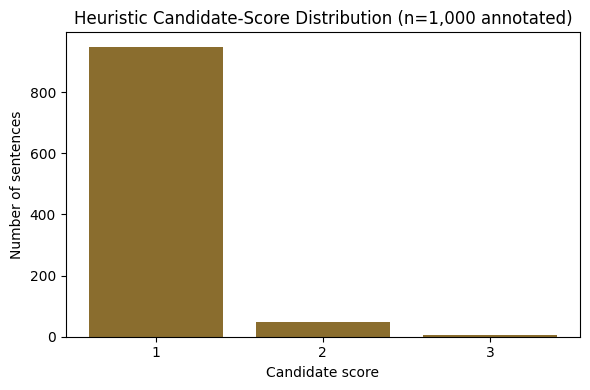

In [98]:
import matplotlib.pyplot as plt
import os

FIGURES_DIR = f"{BASE_PATH}/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

score_counts = annotation_df["candidate_score"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(score_counts.index.astype(str), score_counts.values, color="#8A6D2E")
plt.xlabel("Candidate score")
plt.ylabel("Number of sentences")
plt.title("Heuristic Candidate-Score Distribution (n=1,000 annotated)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/candidate_score_distribution.png", dpi=200)
plt.show()


- Precision, recall and F1 of the heuristic as the score threshold changes

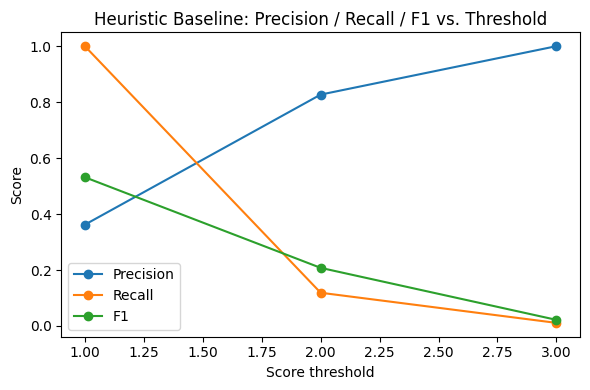

In [99]:
import matplotlib.pyplot as plt
import os
from sklearn.metrics import precision_score, recall_score, f1_score

FIGURES_DIR = f"{BASE_PATH}/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

thresholds = sorted(annotation_df["candidate_score"].unique())
precisions, recalls, f1s = [], [], []

for t in thresholds:
    pred = annotation_df["candidate_score"] >= t
    precisions.append(precision_score(y_true, pred, zero_division=0))
    recalls.append(recall_score(y_true, pred, zero_division=0))
    f1s.append(f1_score(y_true, pred, zero_division=0))

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions, marker="o", label="Precision")
plt.plot(thresholds, recalls, marker="o", label="Recall")
plt.plot(thresholds, f1s, marker="o", label="F1")
plt.xlabel("Score threshold")
plt.ylabel("Score")
plt.title("Heuristic Baseline: Precision / Recall / F1 vs. Threshold")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/heuristic_threshold_curve.png", dpi=200)
plt.show()


In [100]:
evaluation = {
    "annotation_samples": len(annotation_df),
    "valid_claims": int(y_true.sum()),
    "not_claims": int((~y_true).sum()),
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred),
    "recall": recall_score(y_true, y_pred),
    "f1": f1_score(y_true, y_pred),
    "true_positive": int(((y_true == True) & (y_pred == True)).sum()),
    "true_negative": int(((y_true == False) & (y_pred == False)).sum()),
    "false_positive": int(((y_true == False) & (y_pred == True)).sum()),
    "false_negative": int(((y_true == True) & (y_pred == False)).sum())
}

evaluation_df = pd.DataFrame([evaluation])

evaluation_path = (
    f"{BASE_PATH}/results/claim_validation/"
    "candidate_extractor_evaluation_v1.csv"
)

evaluation_df.to_csv(evaluation_path, index=False)

print("Saved:", evaluation_path)
print("Exists:", os.path.exists(evaluation_path))

Saved: /kaggle/working/AGRVF/results/claim_validation/candidate_extractor_evaluation_v1.csv
Exists: True


In [101]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

annotation_df = pd.read_csv(
    f"{BASE_PATH}/results/claim_extraction/"
    "claim_annotation_sample_annotated.csv"
)

annotation_df = annotation_df.dropna(
    subset=["claim_text", "human_label"]
).copy()

print("Annotation data:", annotation_df.shape)
print(annotation_df["human_label"].value_counts())

Annotation data: (1000, 13)
human_label
NOT_CLAIM      638
VALID_CLAIM    362
Name: count, dtype: int64


- Human-annotated label balance for the classifier training set

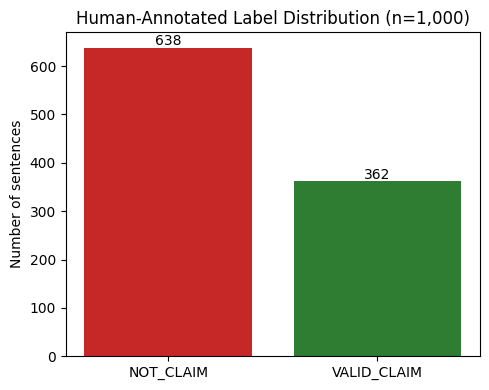

In [102]:
import matplotlib.pyplot as plt
import os

FIGURES_DIR = f"{BASE_PATH}/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

label_counts = annotation_df["human_label"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(label_counts.index, label_counts.values, color=["#C62828", "#2E7D32"])
plt.ylabel("Number of sentences")
plt.title("Human-Annotated Label Distribution (n=1,000)")
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/human_label_distribution.png", dpi=200)
plt.show()


In [103]:
X = annotation_df["claim_text"].astype(str)
y = annotation_df["human_label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Validation:", len(X_val))

Training: 800
Validation: 200


In [104]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

print("Training matrix:", X_train_tfidf.shape)
print("Validation matrix:", X_val_tfidf.shape)

Training matrix: (800, 1890)
Validation matrix: (200, 1890)


- classifier training

In [105]:
claim_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

claim_classifier.fit(X_train_tfidf, y_train)

print("Classifier training complete.")

Classifier training complete.


In [106]:
y_pred = claim_classifier.predict(X_val_tfidf)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1:", f1_score(
    y_val,
    y_pred,
    pos_label="VALID_CLAIM"
))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred,
        target_names=["NOT_CLAIM", "VALID_CLAIM"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Accuracy: 0.85
F1: 0.7945205479452054

Classification Report:
              precision    recall  f1-score   support

   NOT_CLAIM       0.89      0.88      0.88       128
 VALID_CLAIM       0.78      0.81      0.79        72

    accuracy                           0.85       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.85      0.85      0.85       200


Confusion Matrix:
[[112  16]
 [ 14  58]]


## Visual Insights — Classifier Performance

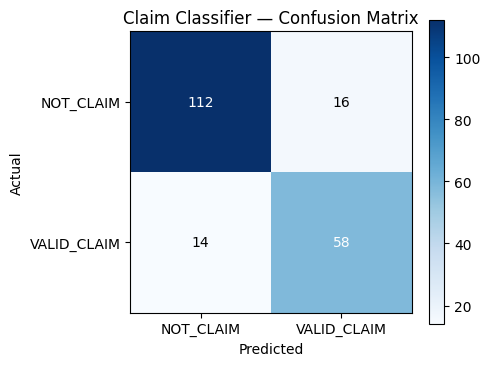

In [107]:
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix

FIGURES_DIR = f"{BASE_PATH}/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

cm = confusion_matrix(y_val, y_pred, labels=["NOT_CLAIM", "VALID_CLAIM"])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Claim Classifier — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["NOT_CLAIM", "VALID_CLAIM"])
plt.yticks([0, 1], ["NOT_CLAIM", "VALID_CLAIM"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/classifier_confusion_matrix.png", dpi=200)
plt.show()


- Baseline heuristic vs. trained classifier, side by side

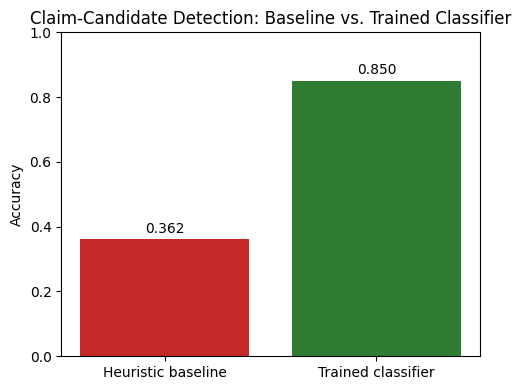

In [108]:
import matplotlib.pyplot as plt
import os

FIGURES_DIR = f"{BASE_PATH}/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

baseline_accuracy = 0.362  # heuristic threshold>=1 baseline, computed above
trained_accuracy = accuracy_score(y_val, y_pred)

labels = ["Heuristic baseline", "Trained classifier"]
accuracies = [baseline_accuracy, trained_accuracy]

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, accuracies, color=["#C62828", "#2E7D32"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Claim-Candidate Detection: Baseline vs. Trained Classifier")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.3f}", ha="center")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/baseline_vs_trained_accuracy.png", dpi=200)
plt.show()


- model saved

In [109]:
import joblib

model_dir = f"{BASE_PATH}/results/claim_validation/models"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(
    vectorizer,
    f"{model_dir}/tfidf_vectorizer_v1.joblib"
)

joblib.dump(
    claim_classifier,
    f"{model_dir}/claim_classifier_logreg_v1.joblib"
)

print("Models saved.")

Models saved.


In [110]:
test_sentences = [
    "This shampoo contains coconut oil.",
    "I absolutely love this product.",
    "It removes stains after repeated use.",
    "The packaging is really pretty."
]

test_matrix = vectorizer.transform(test_sentences)
test_predictions = claim_classifier.predict(test_matrix)

for text, prediction in zip(test_sentences, test_predictions):
    print(f"{prediction:15} | {text}")

VALID_CLAIM     | This shampoo contains coconut oil.
NOT_CLAIM       | I absolutely love this product.
VALID_CLAIM     | It removes stains after repeated use.
VALID_CLAIM     | The packaging is really pretty.


- Final candidate claim dataset

In [111]:
#  Final candidate claim dataset

final_claims = candidate_claims[
    candidate_claims["candidate_score"] >= 1
].copy()

print("Final candidate claims:", final_claims.shape)
print("Unique reviews:", final_claims["claim_id"].nunique())
print("Unique products:", final_claims["product_id"].nunique())

Final candidate claims: (106073, 14)
Unique reviews: 90607
Unique products: 30899


In [112]:
claim_dataset = final_claims[
    [
        "claim_id",
        "sentence_id",
        "product_id",
        "product_name",
        "brand",
        "category",
        "sentence",
        "claim_type",
        "source",
        "timestamp",
        "candidate_score"
    ]
].rename(columns={"sentence": "claim_text"}).copy()

claim_dataset = claim_dataset.reset_index(drop=True)

claim_dataset.insert(
    0,
    "agrvf_claim_id",
    [f"AGRVF_C_{i}" for i in range(len(claim_dataset))]
)

print(claim_dataset.shape)
print(claim_dataset.head())

(106073, 12)
  agrvf_claim_id claim_id sentence_id  product_id  \
0      AGRVF_C_0    AMZ_9     SENT_31  B086QY6T7N   
1      AGRVF_C_1   AMZ_12     SENT_51  B07SLFWZKN   
2      AGRVF_C_2   AMZ_17     SENT_86  B07KG1TWP5   
3      AGRVF_C_3   AMZ_20    SENT_110  B07J3GH1W1   
4      AGRVF_C_4   AMZ_21    SENT_120  B01M7UMAUG   

                                        product_name             brand  \
0  Caroline Keller Keratin Shampoo for dry and da...   Caroline Keller   
1  Keratin Secrets Do It Yourself Home Keratin Sy...   Keratin Secrets   
2  Organic Bamboo Cotton Ear Swabs by Bali Boo - ...          Bali Boo   
3  Manicure and Pedicure Nail Clipper from POWERG...     POWERGROOMING   
4  Philips Sonicare Essence+ Gum Health & Airflos...  Philips Sonicare   

     category                                         claim_text  \
0  All Beauty  It is sulfate free (which is the first thing I...   
1  All Beauty  Then I saw the ingredients after the first tim...   
2  All Beauty  Seco

In [113]:
# 3.26 — Rule-based claim type assignment

def classify_claim_type(text):
    t = text.lower()

    if any(x in t for x in ["contains", "ingredient", "made with", "formulated with"]):
        return "INGREDIENT"

    if any(x in t for x in ["safe", "harmful", "irritat", "allerg", "side effect"]):
        return "HEALTH_SAFETY"

    if any(x in t for x in ["within", "days", "weeks", "hours", "lasts"]):
        return "DURATION"

    if any(x in t for x in ["removes", "cleans", "protects", "kills", "eliminates"]):
        return "PERFORMANCE"

    if any(x in t for x in ["improves", "whitens", "reduces", "prevents", "treats"]):
        return "EFFICACY"

    if any(x in t for x in ["than", "better", "worse", "compared"]):
        return "COMPARATIVE"

    if any(x in t for x in ["use", "apply", "wash", "spray", "brush"]):
        return "USAGE"

    return "OTHER_FACTUAL"


claim_dataset["claim_type"] = claim_dataset["claim_text"].apply(
    classify_claim_type
)

print(claim_dataset["claim_type"].value_counts())

claim_type
OTHER_FACTUAL    63829
USAGE            13797
INGREDIENT        7788
DURATION          7569
COMPARATIVE       4971
PERFORMANCE       4073
HEALTH_SAFETY     3071
EFFICACY           975
Name: count, dtype: int64


- Validate and save final Layer-A claim dataset

In [114]:
# Validate and save final Layer-A claim dataset

print("Shape:", claim_dataset.shape)
print("Duplicate IDs:", claim_dataset["agrvf_claim_id"].duplicated().sum())
print("Missing claim text:", claim_dataset["claim_text"].isna().sum())
print("Missing product IDs:", claim_dataset["product_id"].isna().sum())
print("\nClaim types:")
print(claim_dataset["claim_type"].value_counts())

claim_path = (
    f"{BASE_PATH}/data/processed/claims/"
    "agrvf_claim_dataset_v1.parquet"
)

claim_dataset.to_parquet(claim_path, index=False)

print("\nSaved:", claim_path)
print("Exists:", os.path.exists(claim_path))

Shape: (106073, 12)
Duplicate IDs: 0
Missing claim text: 0
Missing product IDs: 0

Claim types:
claim_type
OTHER_FACTUAL    63829
USAGE            13797
INGREDIENT        7788
DURATION          7569
COMPARATIVE       4971
PERFORMANCE       4073
HEALTH_SAFETY     3071
EFFICACY           975
Name: count, dtype: int64

Saved: /kaggle/working/AGRVF/data/processed/claims/agrvf_claim_dataset_v1.parquet
Exists: True


In [115]:
check = pd.read_parquet(claim_path)

print("Reloaded:", check.shape)
print("Columns:", check.columns.tolist())

Reloaded: (106073, 12)
Columns: ['agrvf_claim_id', 'claim_id', 'sentence_id', 'product_id', 'product_name', 'brand', 'category', 'claim_text', 'claim_type', 'source', 'timestamp', 'candidate_score']


In [1]:
import os, shutil

BASE_PATH = "/kaggle/working/AGRVF"
STAGE_DIR = "/kaggle/working/AGRVF_export"
ZIP_PATH  = "/kaggle/working/AGRVF_LayerA_output"

if os.path.exists(STAGE_DIR):
    shutil.rmtree(STAGE_DIR)
os.makedirs(STAGE_DIR)

# Required by agrvf.ipynb (Layers B–D)
required_files = [
    "data/processed/claims/agrvf_claim_dataset_v1.parquet",
    "data/processed/claims/agrvf_sentence_dataset_v1.parquet",
    "data/processed/amazon/amazon_products_agrvf.parquet",
    "data/processed/fever/fever_train_agrvf.parquet",
    "data/processed/scifact/scifact_train_agrvf.parquet",
    "data/processed/scifact/scifact_corpus_agrvf.parquet",
    "data/processed/openbeautyfacts/openbeautyfacts_agrvf.parquet",
]

# Not required by agrvf.ipynb, but worth keeping for reproducibility / the paper
optional_files = [
    "data/processed/claims/agrvf_claim_candidates_v1.parquet",
    "data/processed/scifact/scifact_dev_agrvf.parquet",
    "data/processed/scifact/scifact_test_agrvf.parquet",
    "results/claim_validation/models/tfidf_vectorizer_v1.joblib",
    "results/claim_validation/models/claim_classifier_logreg_v1.joblib",
]

def copy_in(rel_path, dest_root):
    src = os.path.join(BASE_PATH, rel_path)
    dst = os.path.join(dest_root, rel_path)
    if not os.path.exists(src):
        print("MISSING (skipped):", src)
        return
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)
    print("Copied:", rel_path)

print("== Required (needed by agrvf.ipynb) ==")
req_root = os.path.join(STAGE_DIR, "required_for_agrvf_notebook")
for f in required_files:
    copy_in(f, req_root)

print("\n== Optional / archival (models, paper assets) ==")
opt_root = os.path.join(STAGE_DIR, "archival_and_paper_assets")
for f in optional_files:
    copy_in(f, opt_root)

for sub in ["results/figures", "results/data_validation"]:
    src = os.path.join(BASE_PATH, sub)
    if os.path.isdir(src):
        shutil.copytree(src, os.path.join(opt_root, sub), dirs_exist_ok=True)
        print("Copied:", sub + "/")

shutil.make_archive(ZIP_PATH, "zip", STAGE_DIR)
size_mb = os.path.getsize(ZIP_PATH + ".zip") / (1024**2)
print(f"\nZip created: {ZIP_PATH}.zip  ({size_mb:.1f} MB)")

== Required (needed by agrvf.ipynb) ==
Copied: data/processed/claims/agrvf_claim_dataset_v1.parquet
Copied: data/processed/claims/agrvf_sentence_dataset_v1.parquet
Copied: data/processed/amazon/amazon_products_agrvf.parquet
Copied: data/processed/fever/fever_train_agrvf.parquet
Copied: data/processed/scifact/scifact_train_agrvf.parquet
Copied: data/processed/scifact/scifact_corpus_agrvf.parquet
Copied: data/processed/openbeautyfacts/openbeautyfacts_agrvf.parquet

== Optional / archival (models, paper assets) ==
Copied: data/processed/claims/agrvf_claim_candidates_v1.parquet
Copied: data/processed/scifact/scifact_dev_agrvf.parquet
Copied: data/processed/scifact/scifact_test_agrvf.parquet
Copied: results/claim_validation/models/tfidf_vectorizer_v1.joblib
Copied: results/claim_validation/models/claim_classifier_logreg_v1.joblib
Copied: results/figures/
Copied: results/data_validation/

Zip created: /kaggle/working/AGRVF_LayerA_output.zip  (141.4 MB)
